In [3]:
# Import iniziali
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from tqdm import tqdm
import os
import nibabel as nib
from skimage.transform import resize


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 29 columns):
 #   Column                                                                  Non-Null Count  Dtype  
---  ------                                                                  --------------  -----  
 0   id                                                                      60 non-null     int64  
 1   gender                                                                  60 non-null     object 
 2   age                                                                     60 non-null     int64  
 3   age_of_onset                                                            60 non-null     int64  
 4   edss                                                                    60 non-null     float64
 5   does_the_time_difference_between_mri_acquisition_and_edss_<_two_months  60 non-null     object 
 6   types_of_medicines                                                      60 non-null 

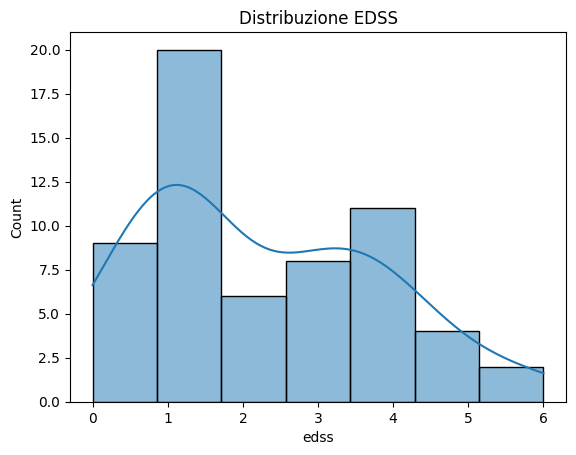

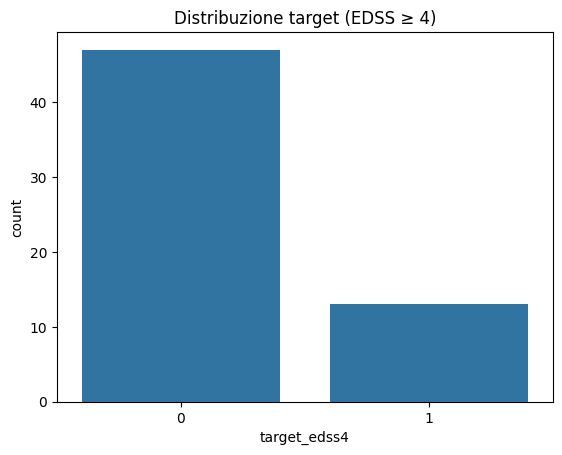

In [4]:
# Caricamento dati clinici
clinical_df = pd.read_excel("Dataset/clinical_data.xlsx", header=1)

# Statistiche base
clinical_df.columns = [c.strip().lower().replace(" ", "_") for c in clinical_df.columns]
clinical_df.info()
clinical_df.describe()
sns.histplot(clinical_df["edss"], kde=True)
plt.title("Distribuzione EDSS")
plt.show()

# Target binario EDSS ≥ 4
clinical_df["target_edss4"] = (clinical_df["edss"] >= 4).astype(int)
sns.countplot(x="target_edss4", data=clinical_df)
plt.title("Distribuzione target (EDSS ≥ 4)")
plt.show()

In [ ]:
# Pulizia dati clinici
threshold = 0.3  # Rimuove colonne con >30% missing
clinical_df = clinical_df.loc[:, clinical_df.isnull().mean() < threshold]

num_cols = clinical_df.select_dtypes(include=np.number).columns
clinical_df[num_cols] = clinical_df[num_cols].fillna(clinical_df[num_cols].median())

cat_cols = clinical_df.select_dtypes(include="object").columns
clinical_df[cat_cols] = clinical_df[cat_cols].fillna("Unknown")

# One-hot encoding
categorical = clinical_df.select_dtypes(include="object")
#codifica di variabili categoriche
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(categorical)
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical.columns))

numerics = clinical_df.select_dtypes(include=np.number).drop(columns=["edss", "target_edss4"])
X_clinical = pd.concat([numerics.reset_index(drop=True), encoded_df], axis=1)
y_clinical = clinical_df["target_edss4"]

In [ ]:
# Funzione per caricare immagini
def load_image_data(base_dir="Dataset", img_shape=(128, 128, 64)):
    image_types = ["Flair", "LesionSeg-Flair", "LesionSeg-T1", "LesionSeg-T2", "T1", "T2"]
    image_data = {}

    for i in tqdm(range(1, 61), desc="Caricamento immagini"):
        patient_id = i
        #Merge tra tabelle
        folder_path = os.path.join(base_dir, f"Patient-{i}")
        patient_images = {}

        for img_type in image_types:
            filename = f"{i}-{img_type}.nii"
            file_path = os.path.join(folder_path, filename)

            if os.path.exists(file_path):
                try:
                    img = nib.load(file_path).get_fdata()
                    img = (img - np.min(img)) / (np.max(img) - np.min(img))
                    img = resize(img, img_shape, mode="constant", anti_aliasing=True)
                    patient_images[img_type] = img
                except Exception as e:
                    print(f"Errore caricando {file_path}: {e}")
            else:
                print(f"File mancante: {filename}")

        if patient_images:
            image_data[patient_id] = patient_images

    return image_data


In [7]:
# Esegui caricamento immagini
image_data = load_image_data()
print(f"Pazienti caricati: {len(image_data)}")

Caricamento immagini:  97%|█████████▋| 58/60 [03:16<00:08,  4.14s/it]C:\Users\acer\AppData\Local\Temp\ipykernel_16684\1545411993.py:18: RuntimeWarning: invalid value encountered in divide
  img = (img - np.min(img)) / (np.max(img) - np.min(img))
C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skimage\transform\_warps.py:738: RuntimeWarning: All-NaN slice encountered
  min_val = min_func(input_image)
C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skimage\transform\_warps.py:742: RuntimeWarning: All-NaN slice encountered
  max_val = max_func(input_image)
C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skimage\transform\_warps.py:749: RuntimeWarning: All-NaN slice encountered
  and min_func(output_image) <= cval <= max_fun

Pazienti caricati: 60


In [37]:
# Usa direttamente la colonna "ID" del file Excel
clinical_df["patient_id"] = clinical_df["id"].astype(int)

# Filtra solo i pazienti presenti nelle immagini
valid_ids = list(image_data.keys())
clinical_df = clinical_df[clinical_df["patient_id"].isin(valid_ids)]

# Allinea le feature cliniche e le etichette in base al nuovo indice
X_clinical = X_clinical.loc[clinical_df.index]
y_clinical = y_clinical.loc[clinical_df.index]

print(f"Pazienti dopo allineamento: {len(clinical_df)}")


Pazienti dopo allineamento: 60


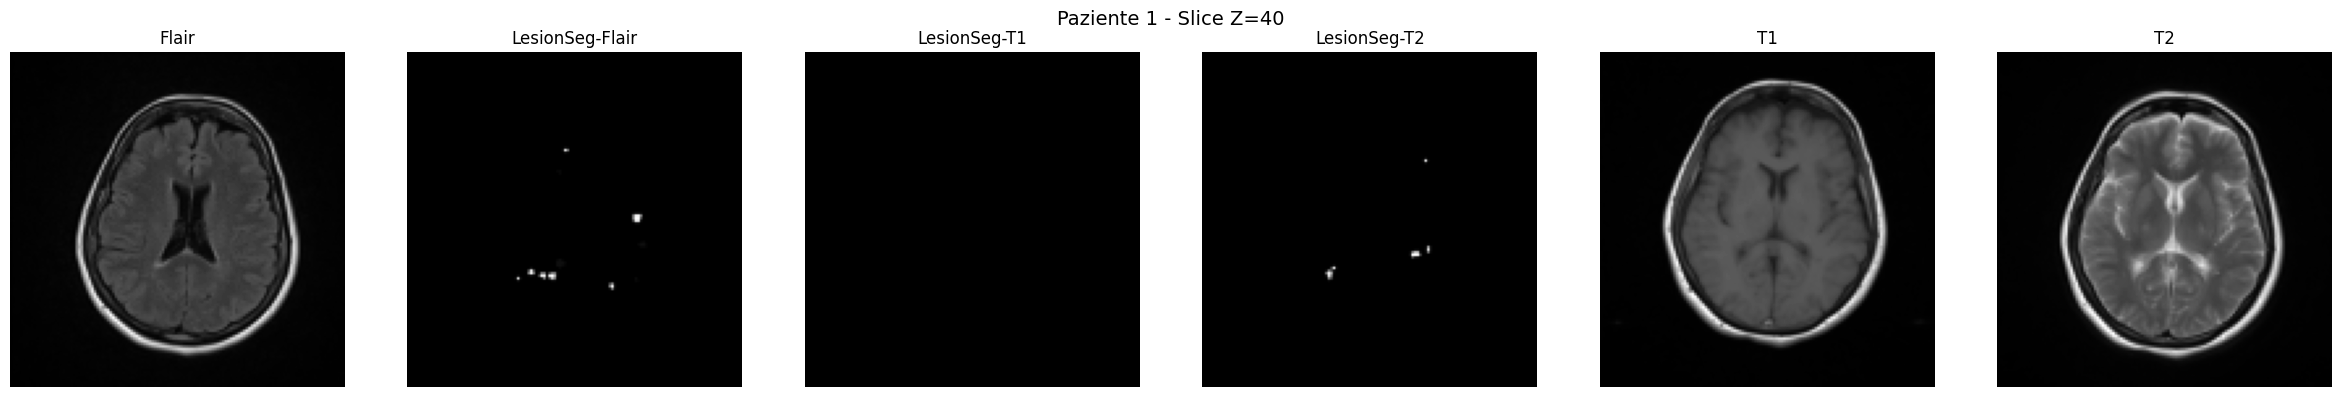

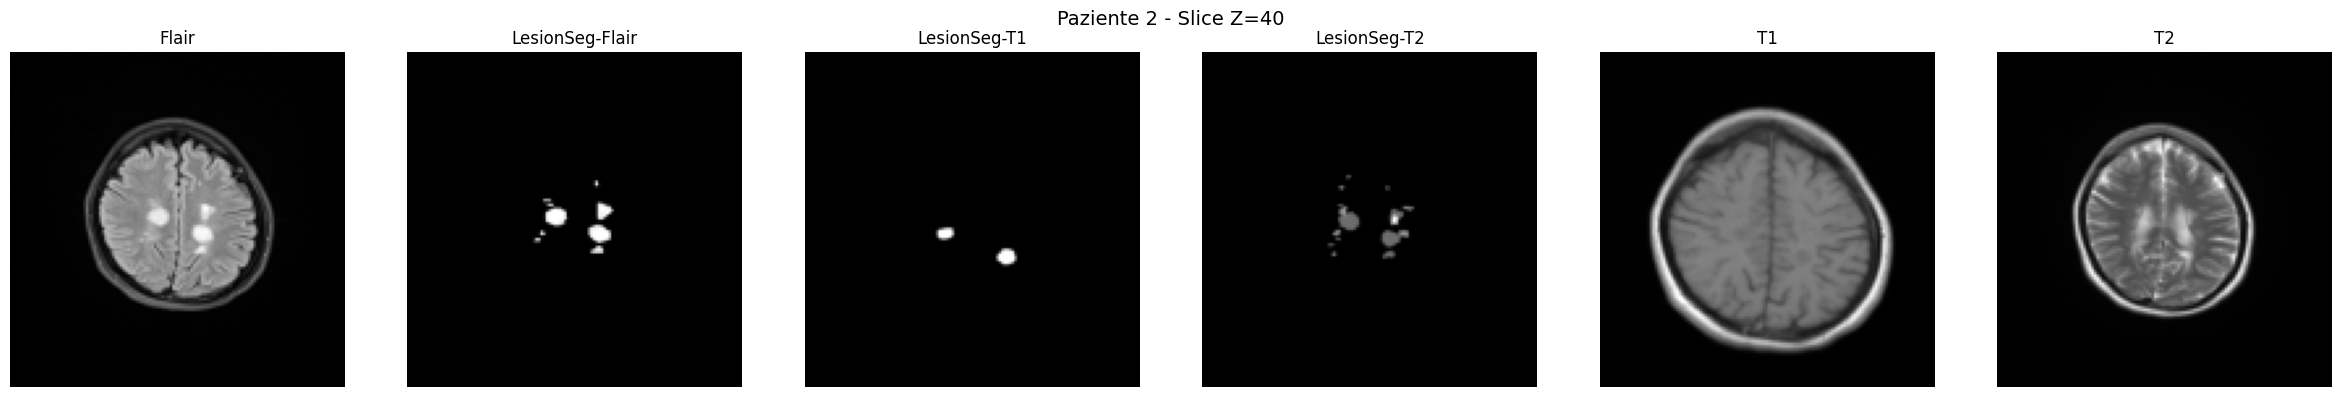

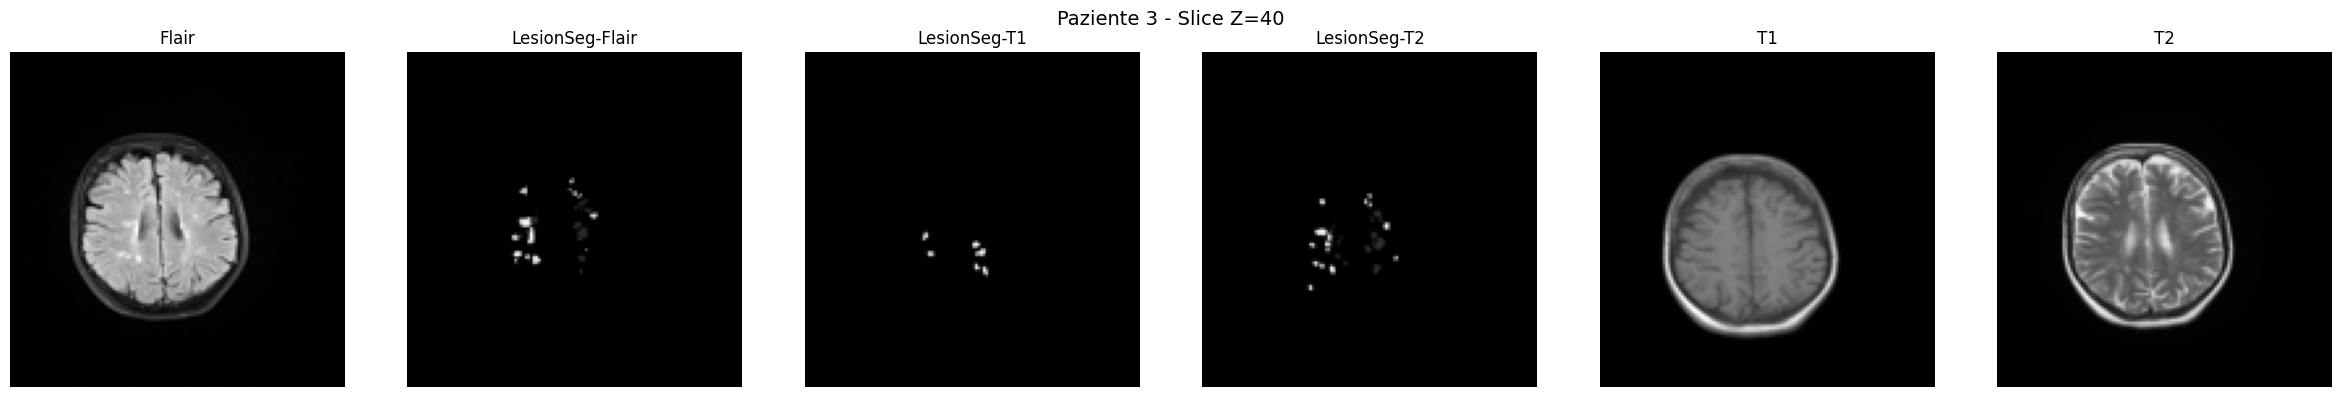

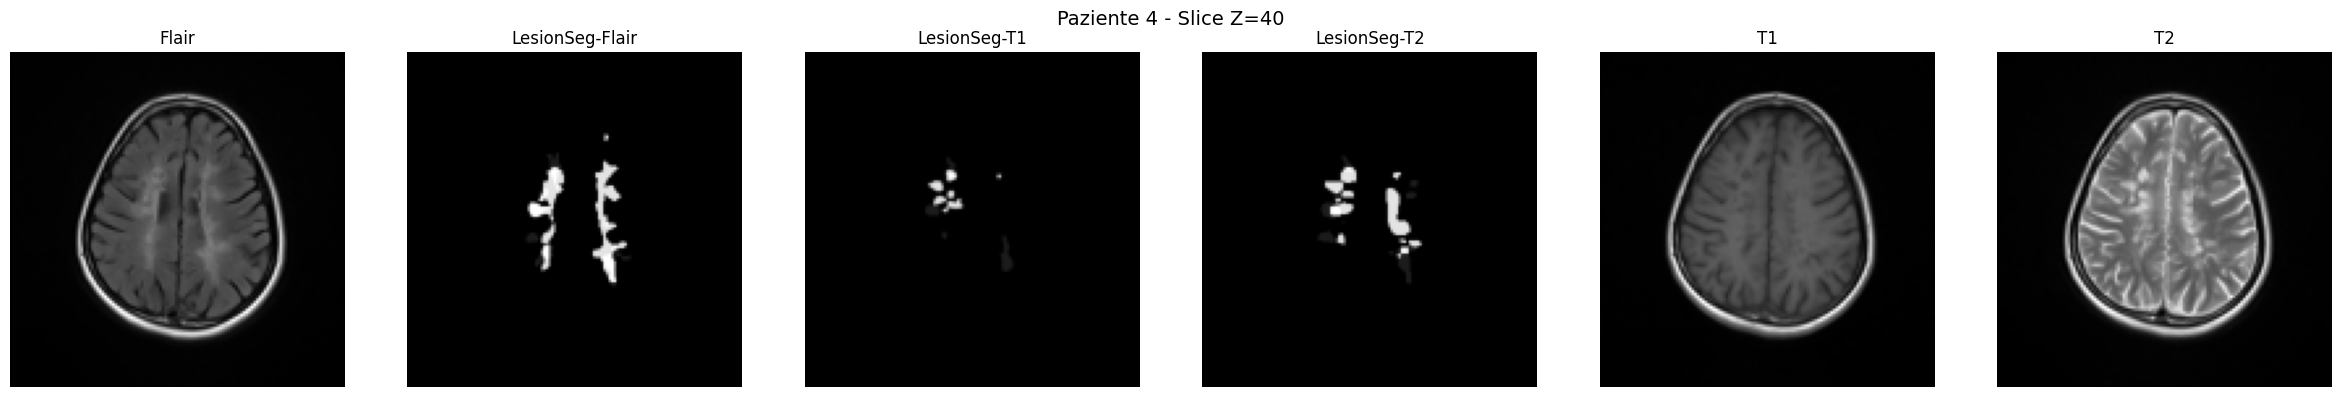

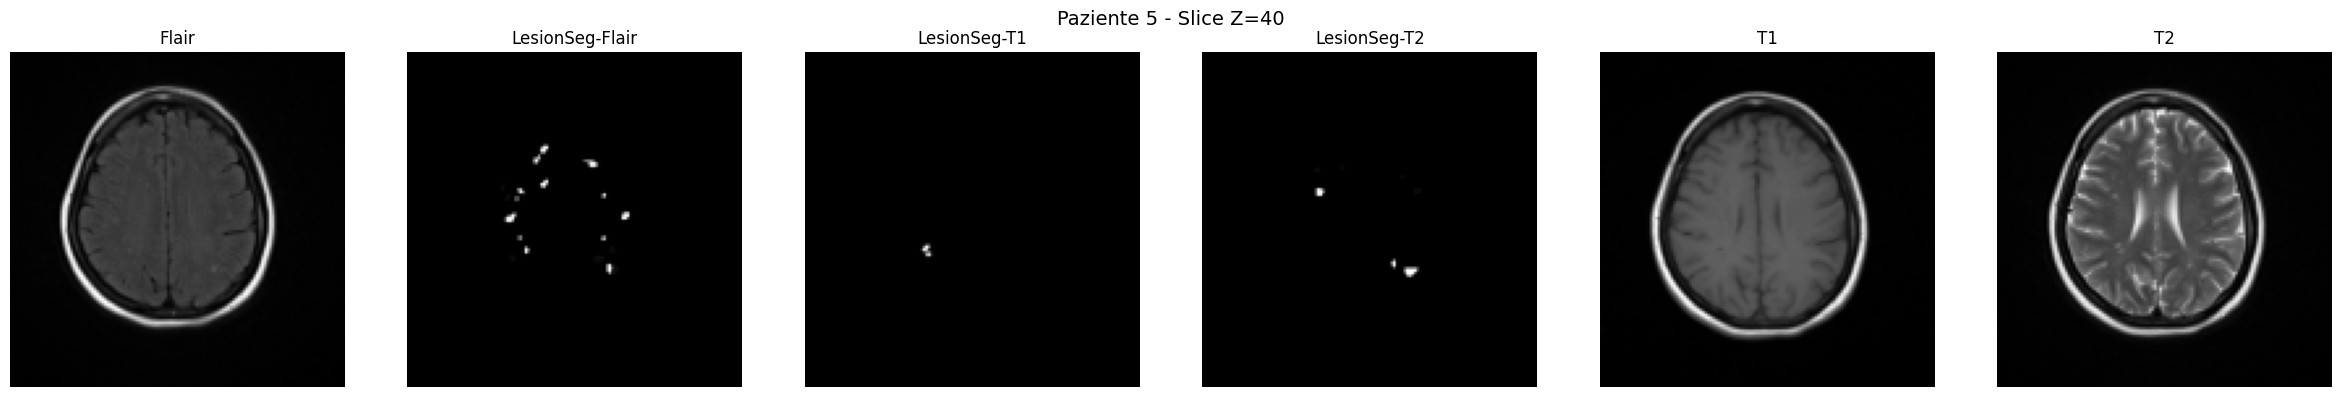

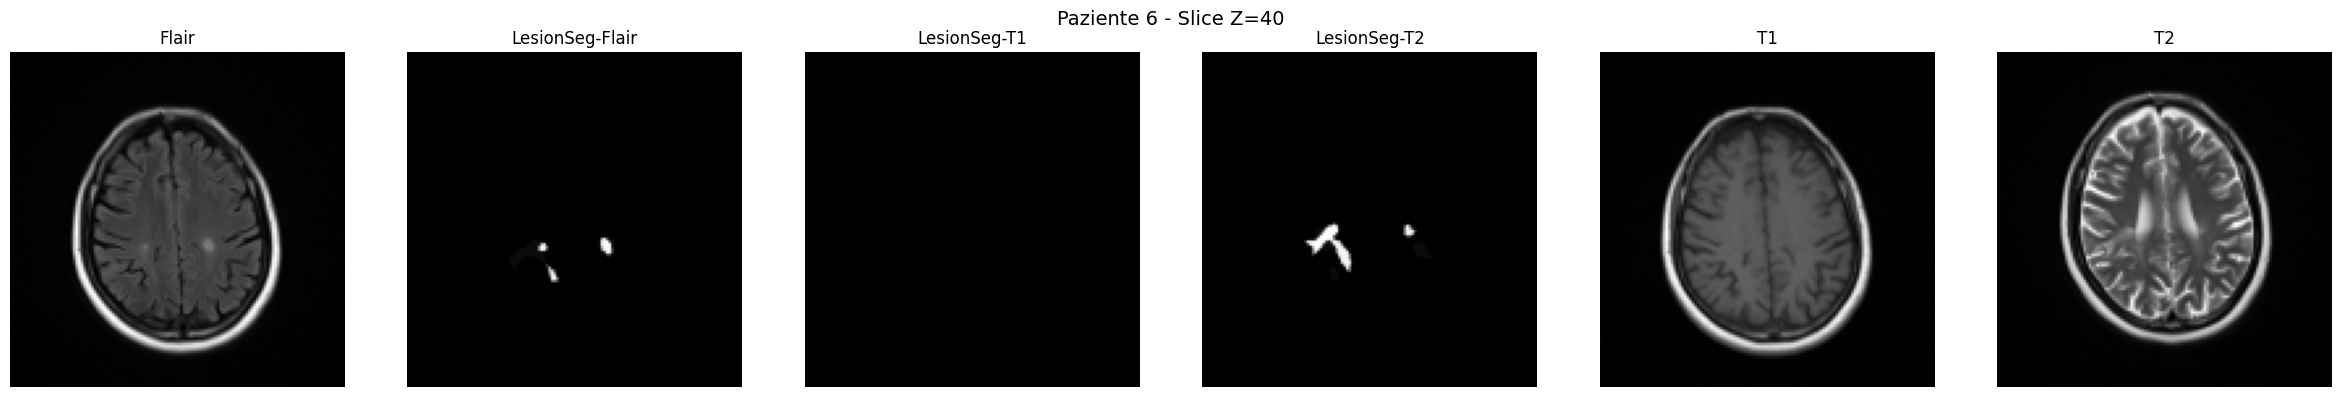

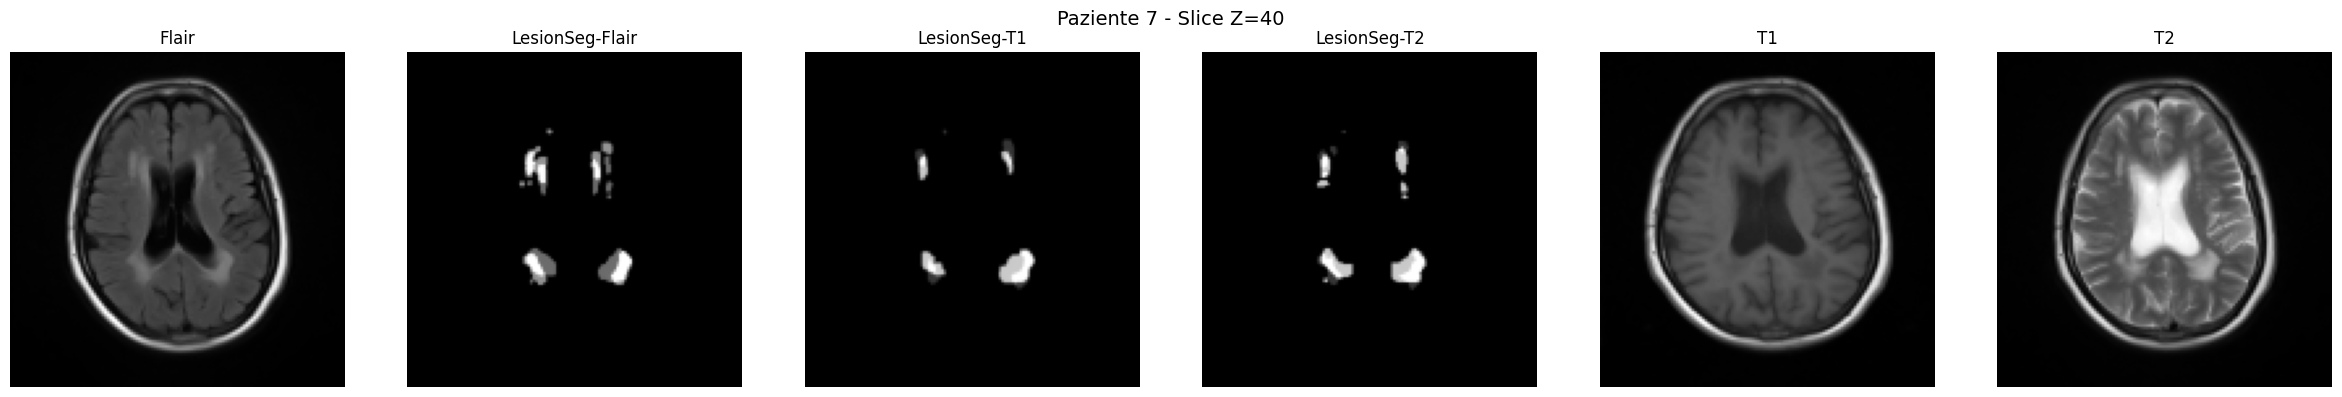

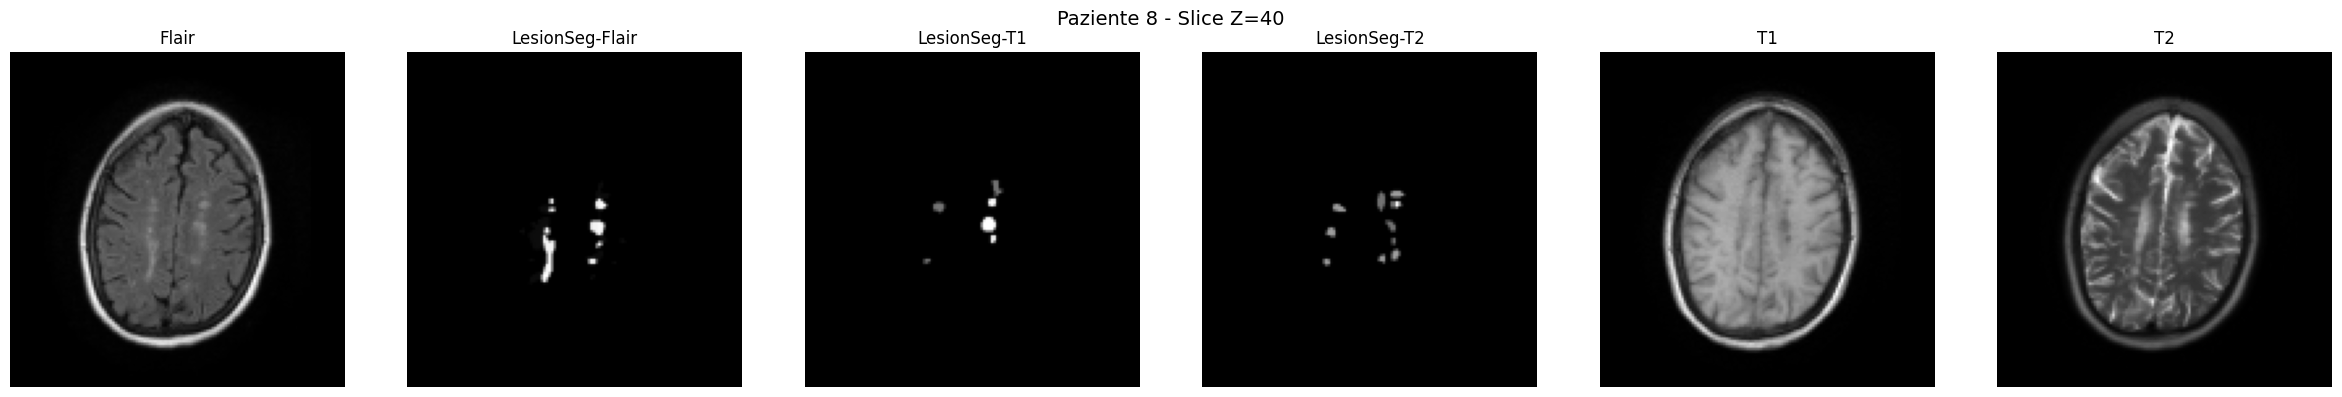

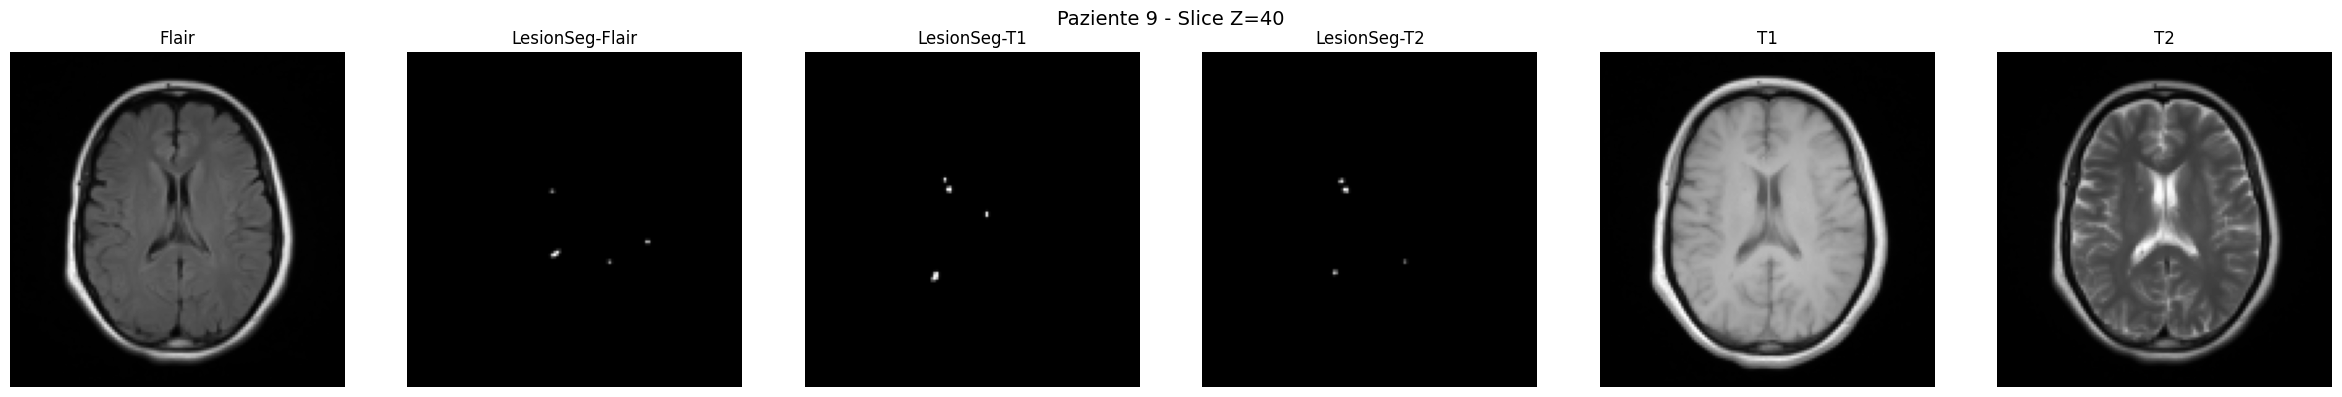

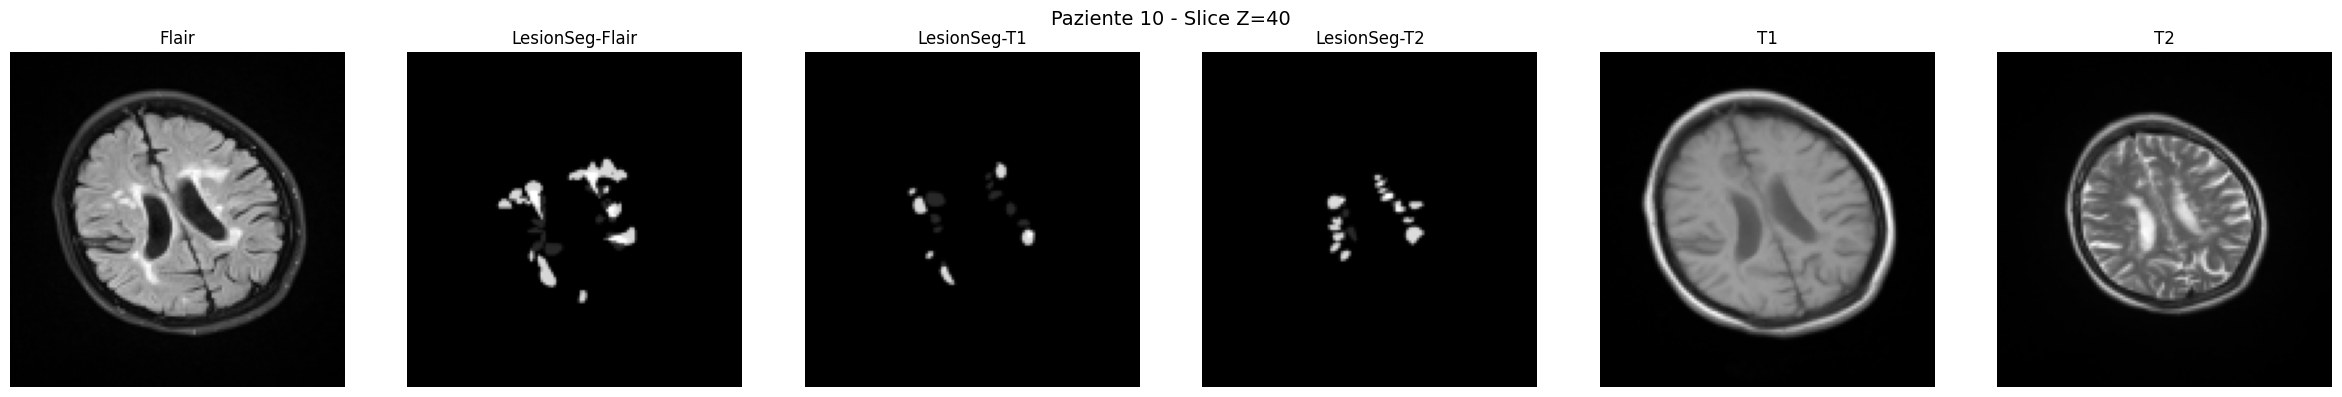

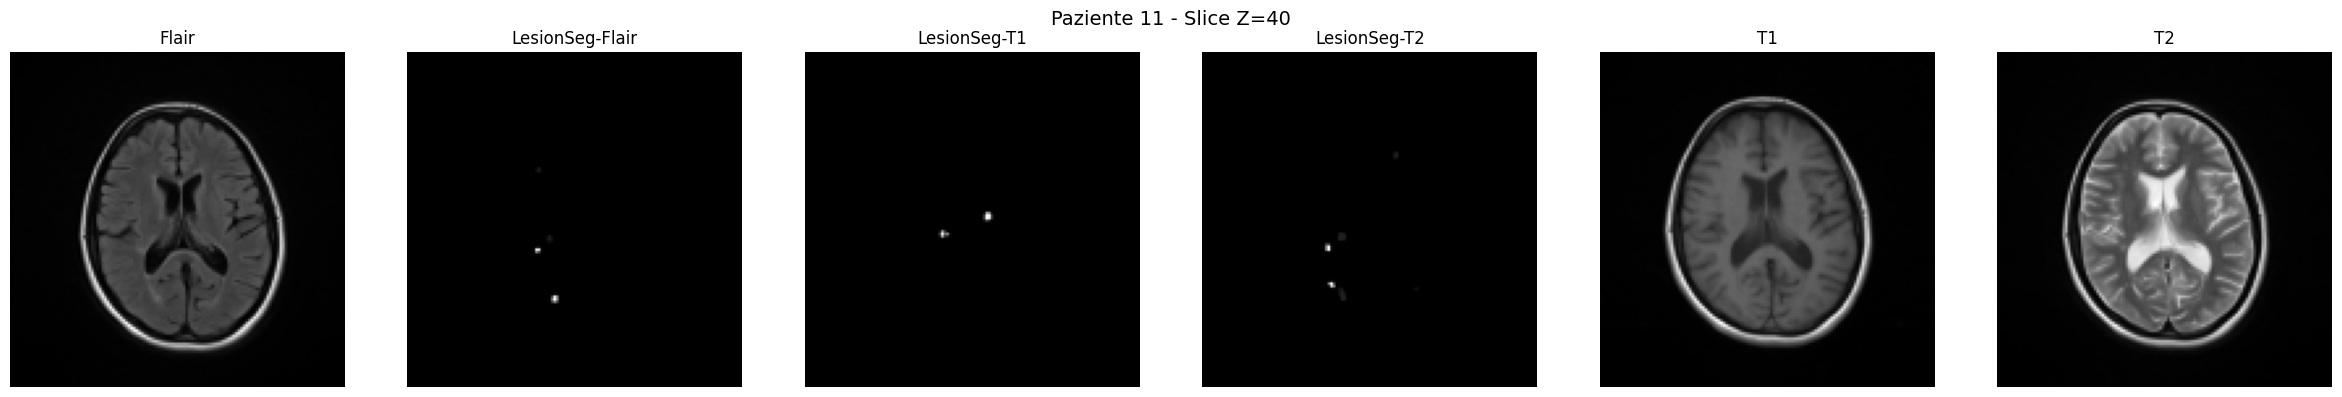

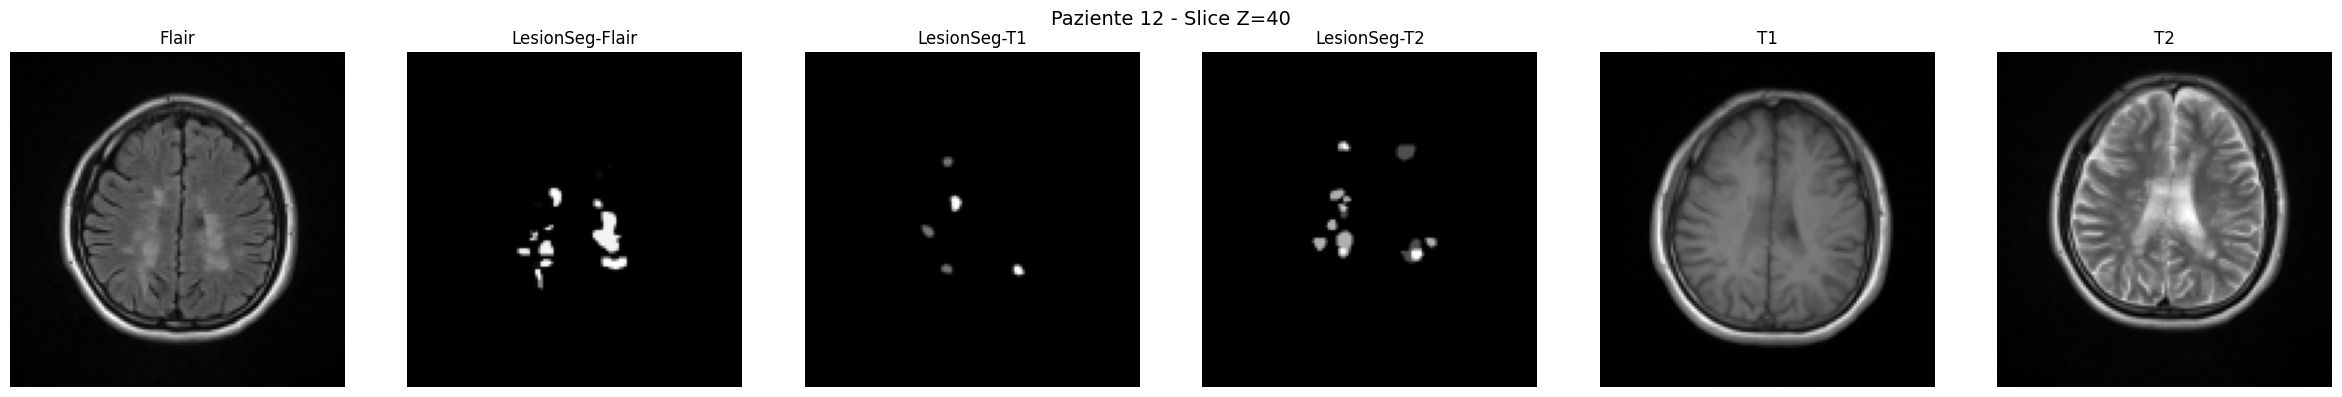

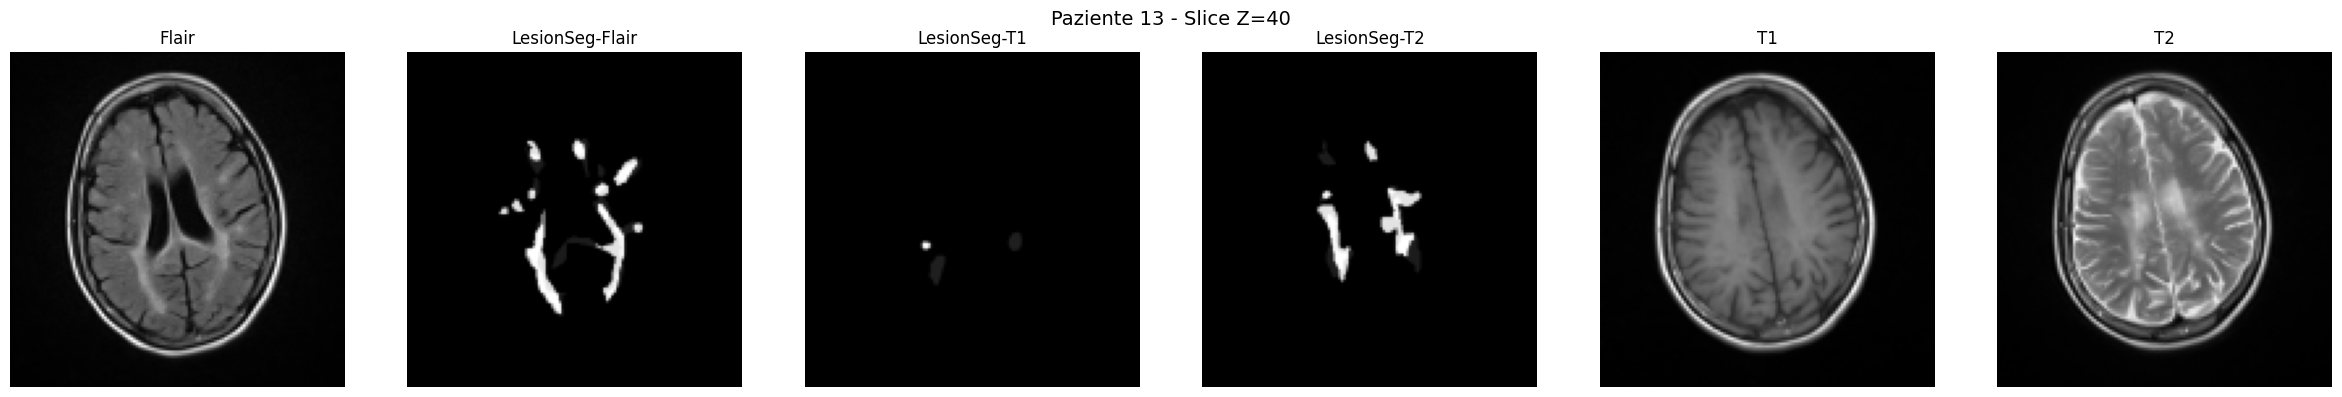

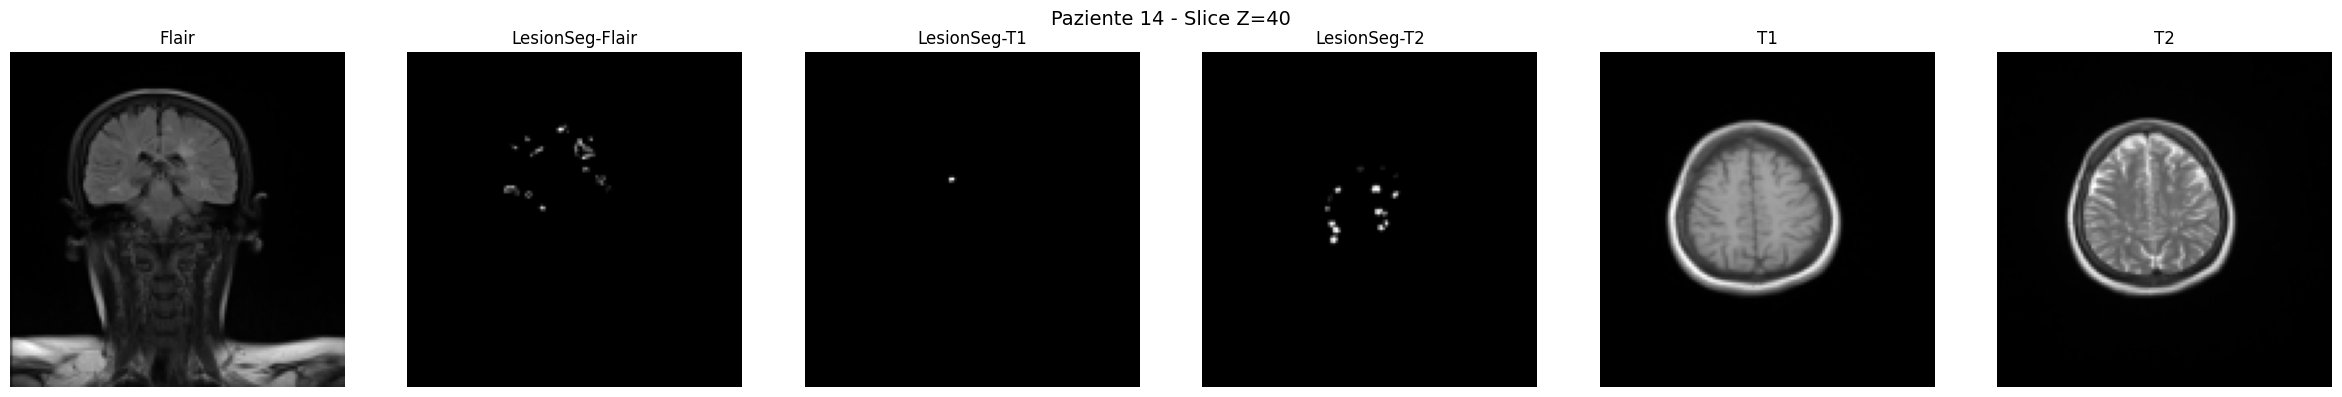

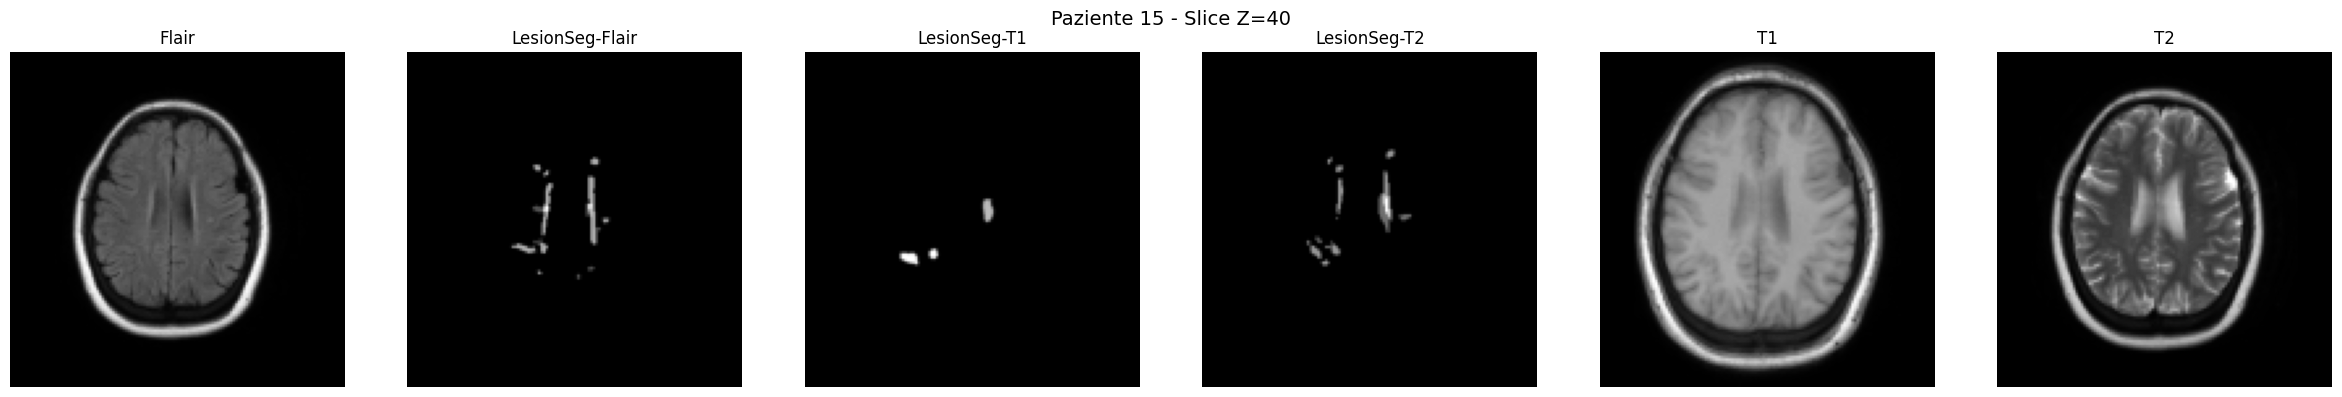

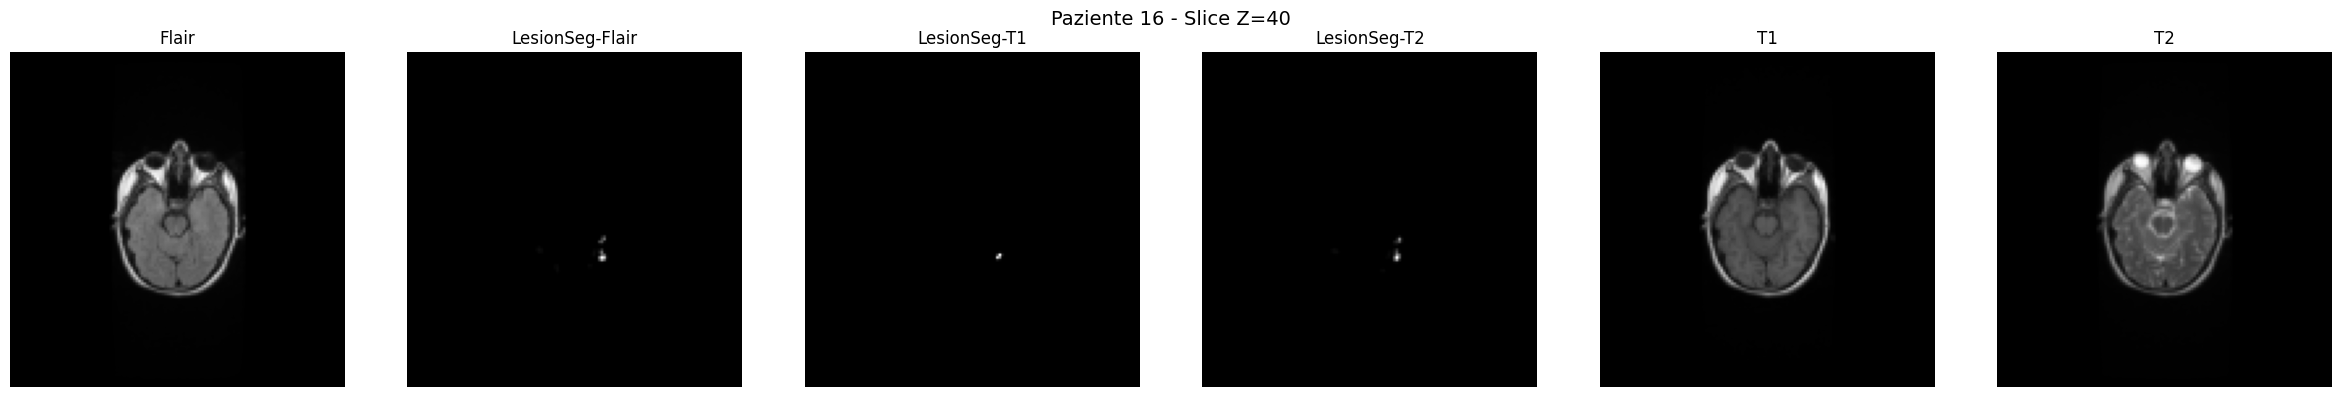

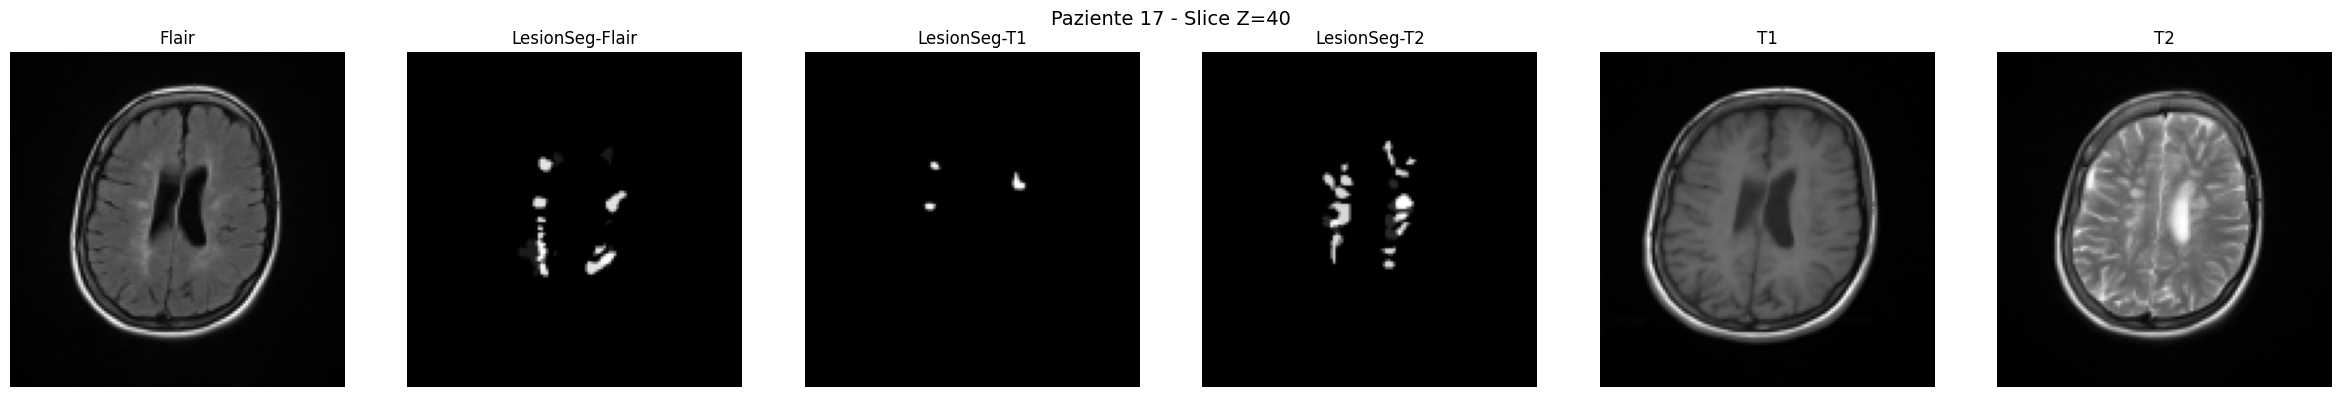

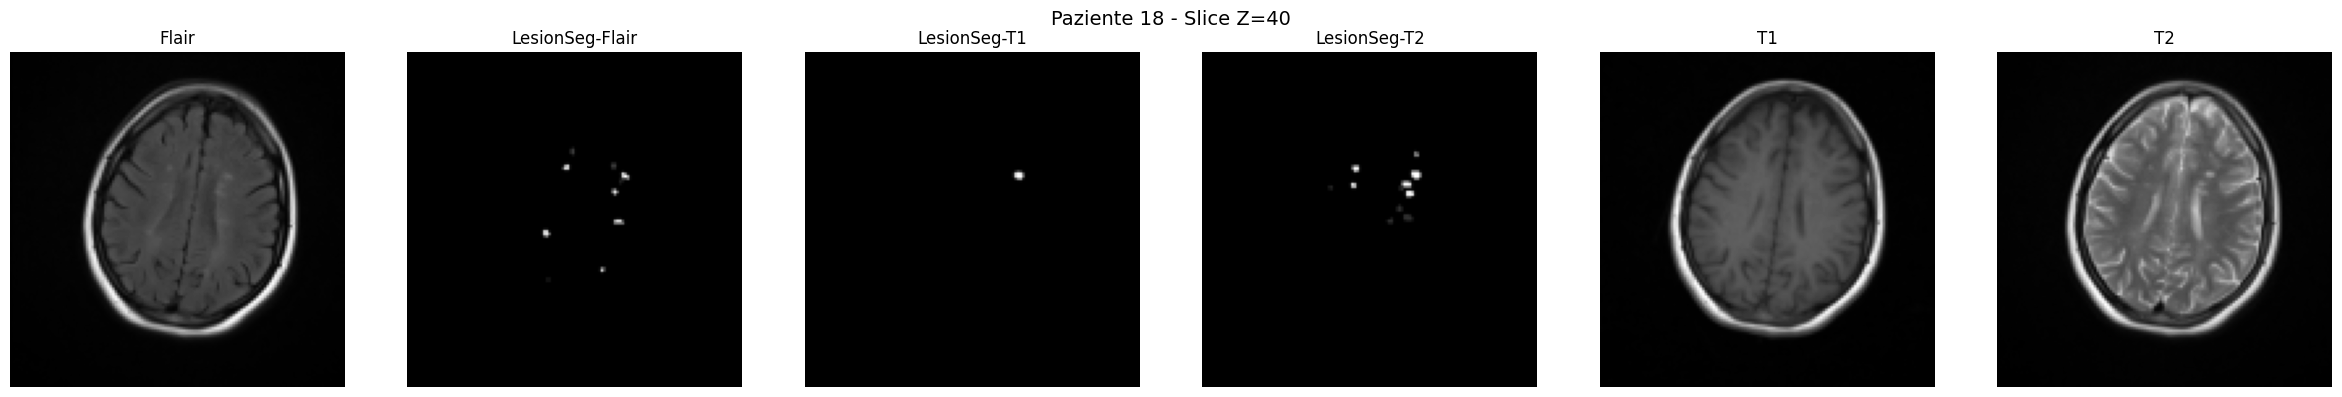

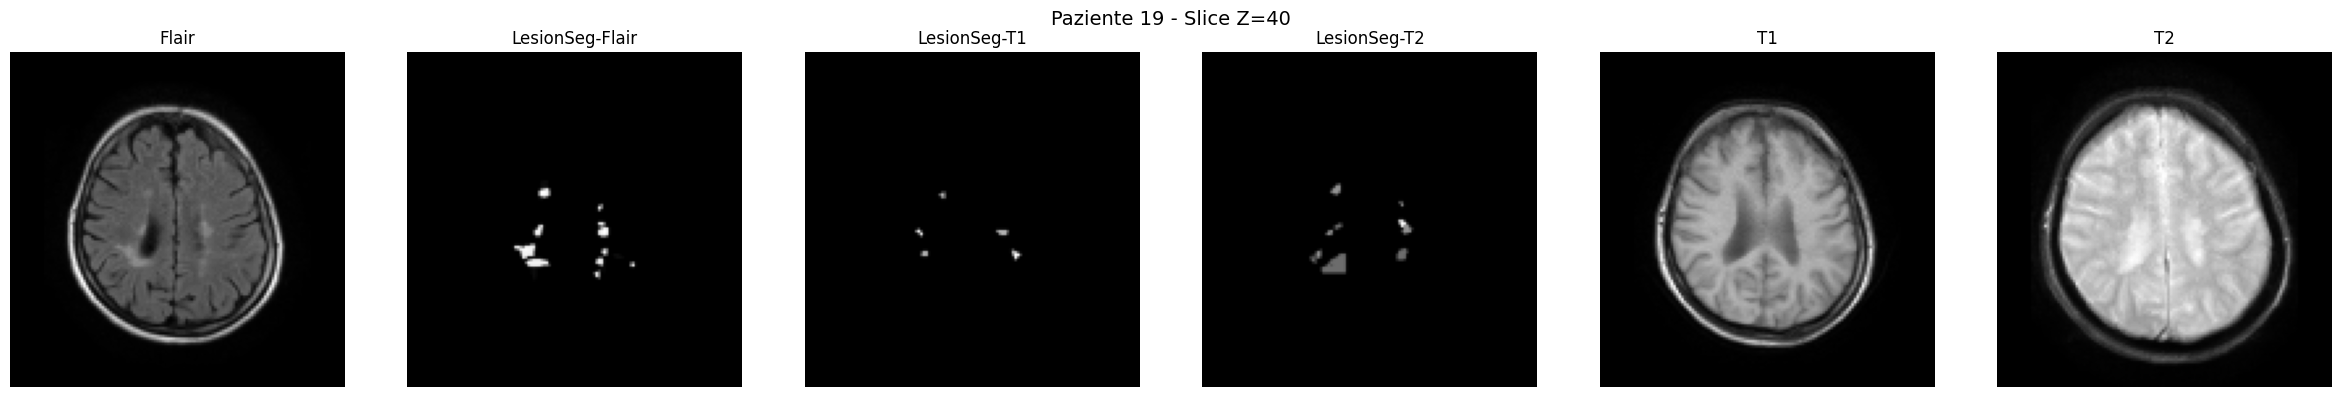

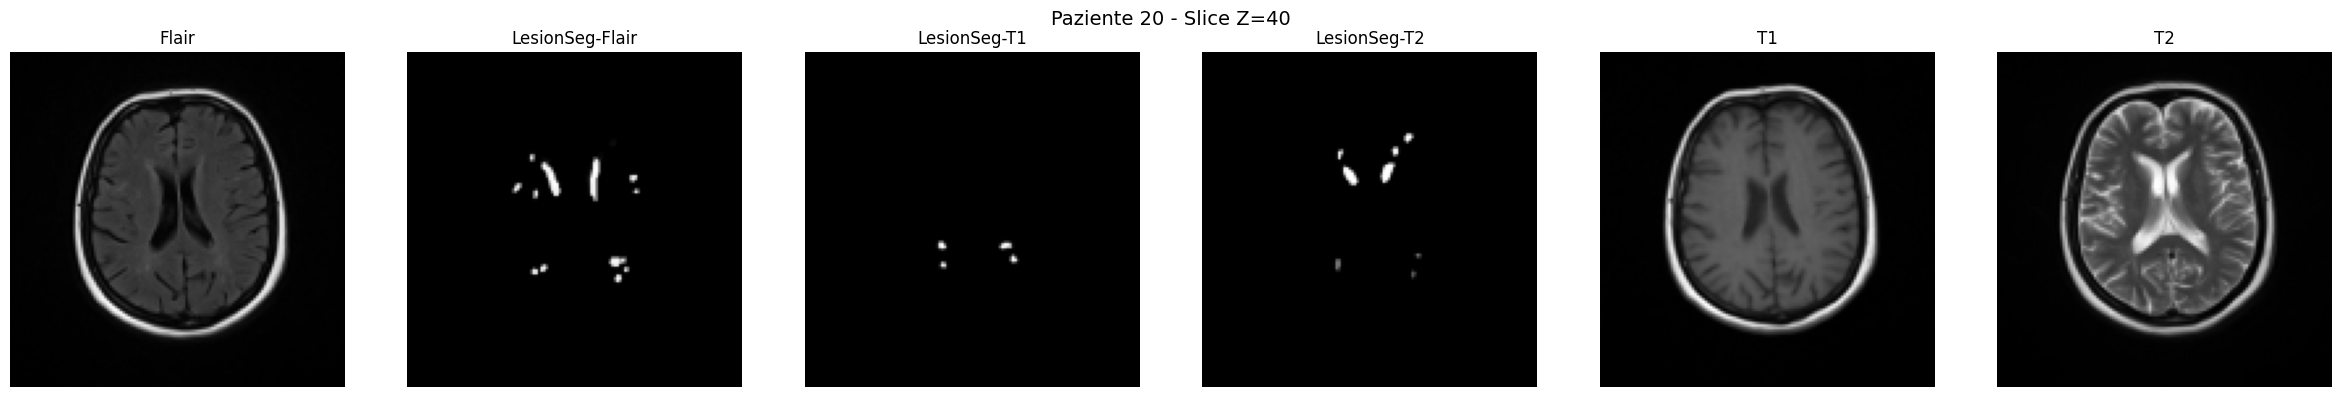

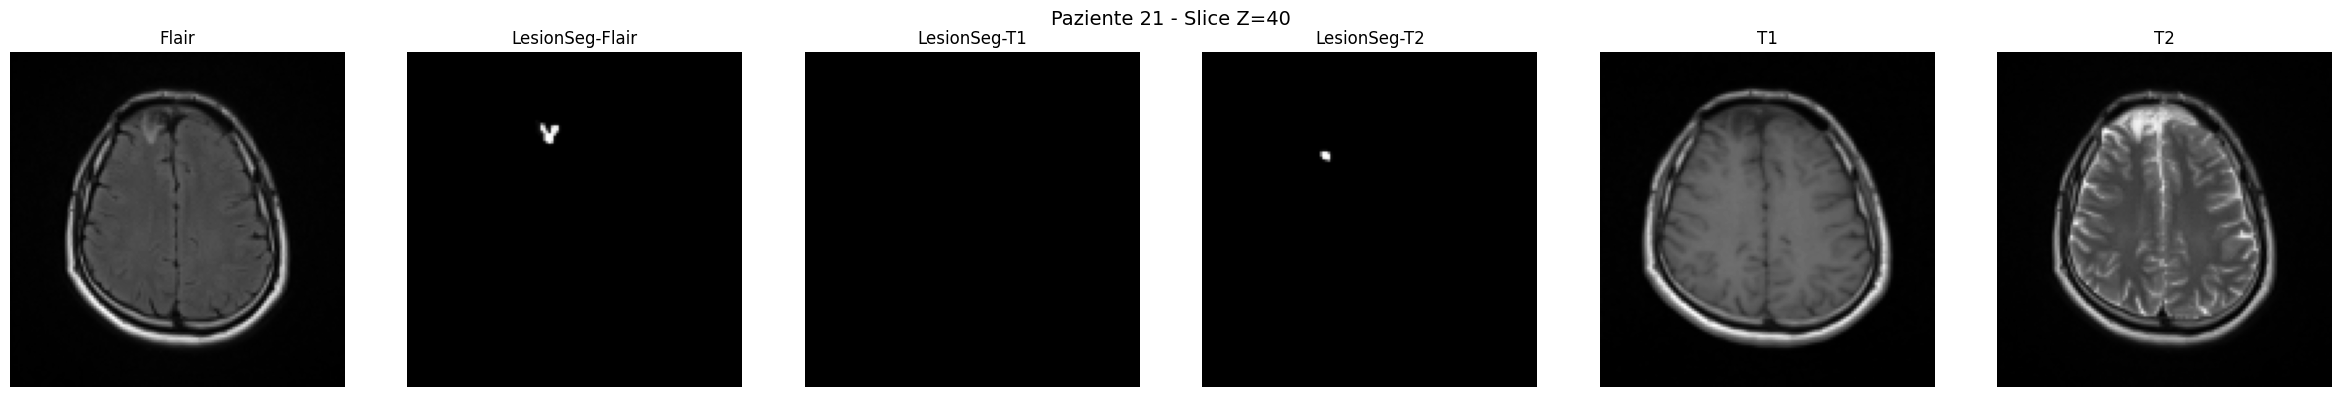

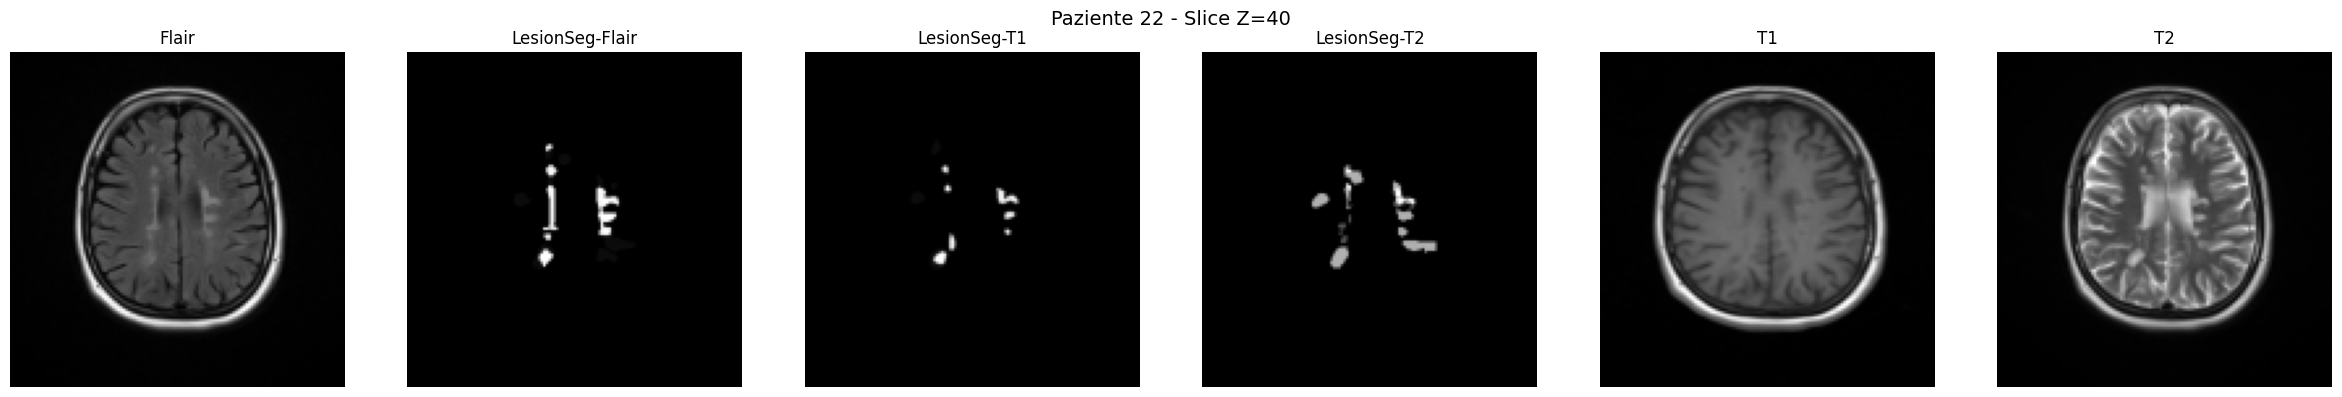

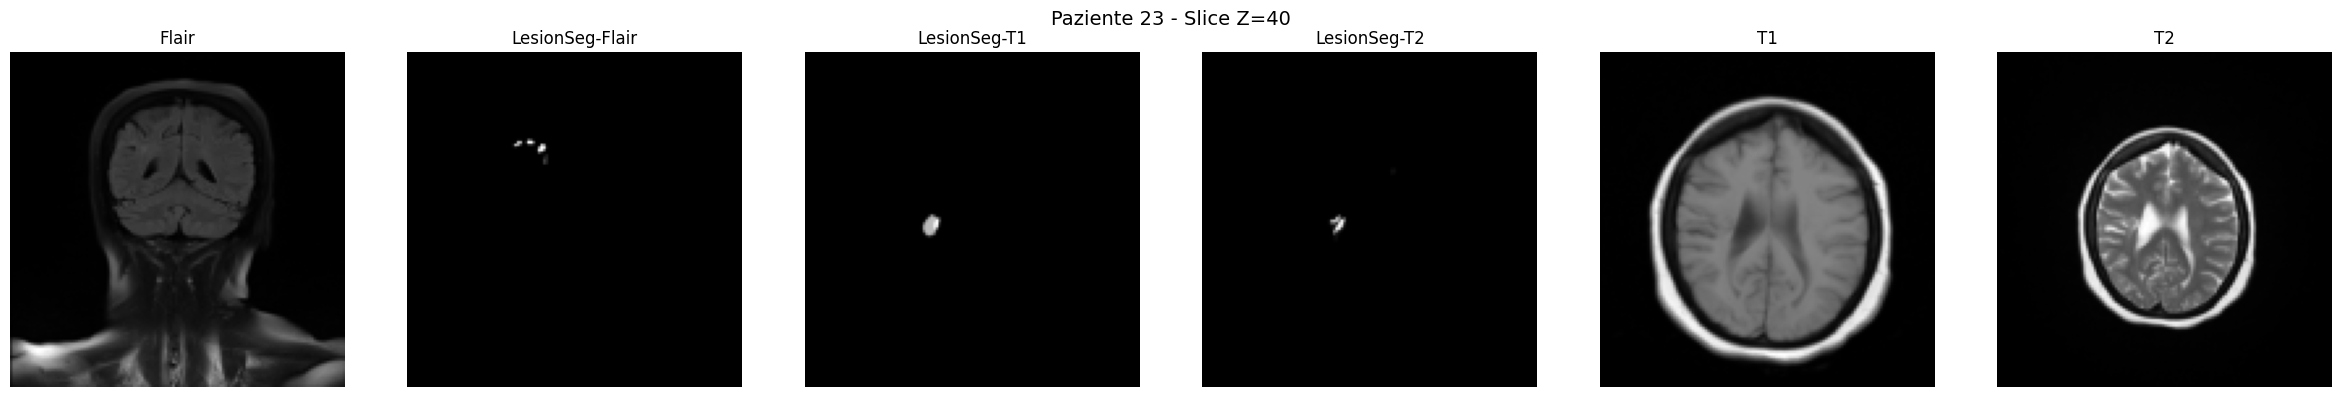

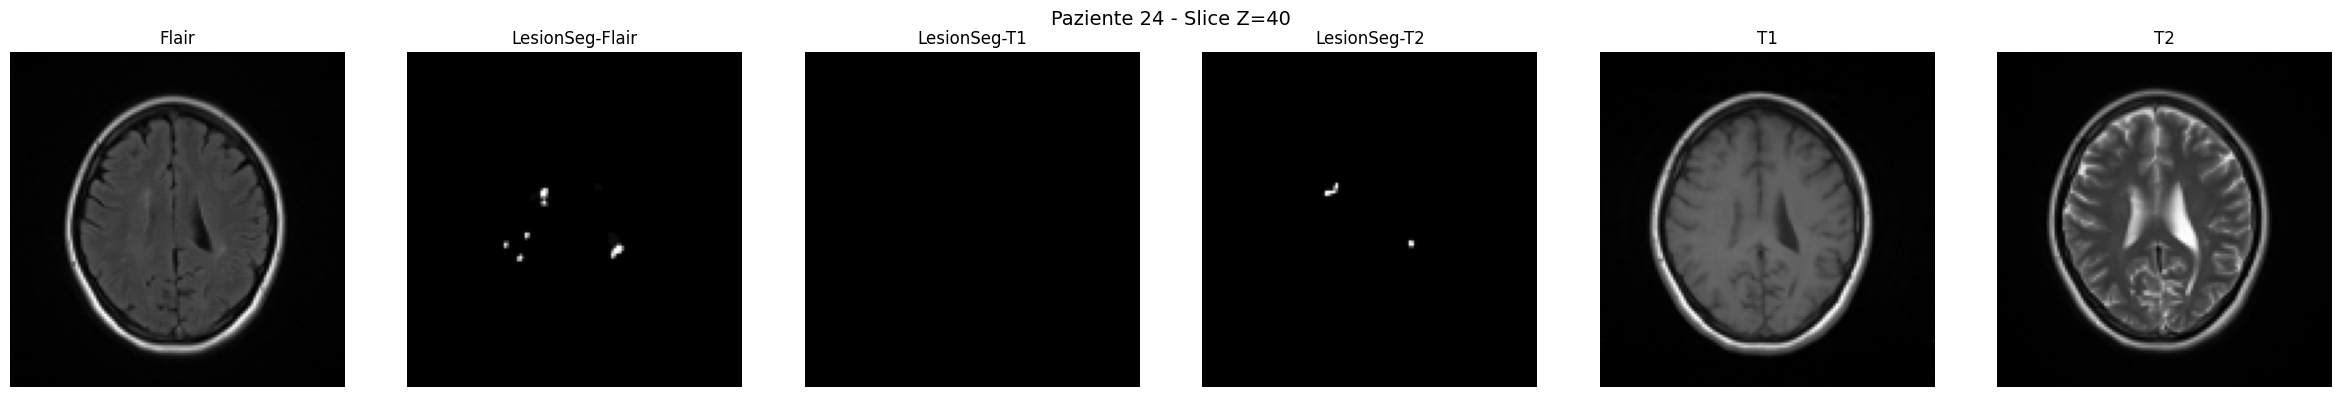

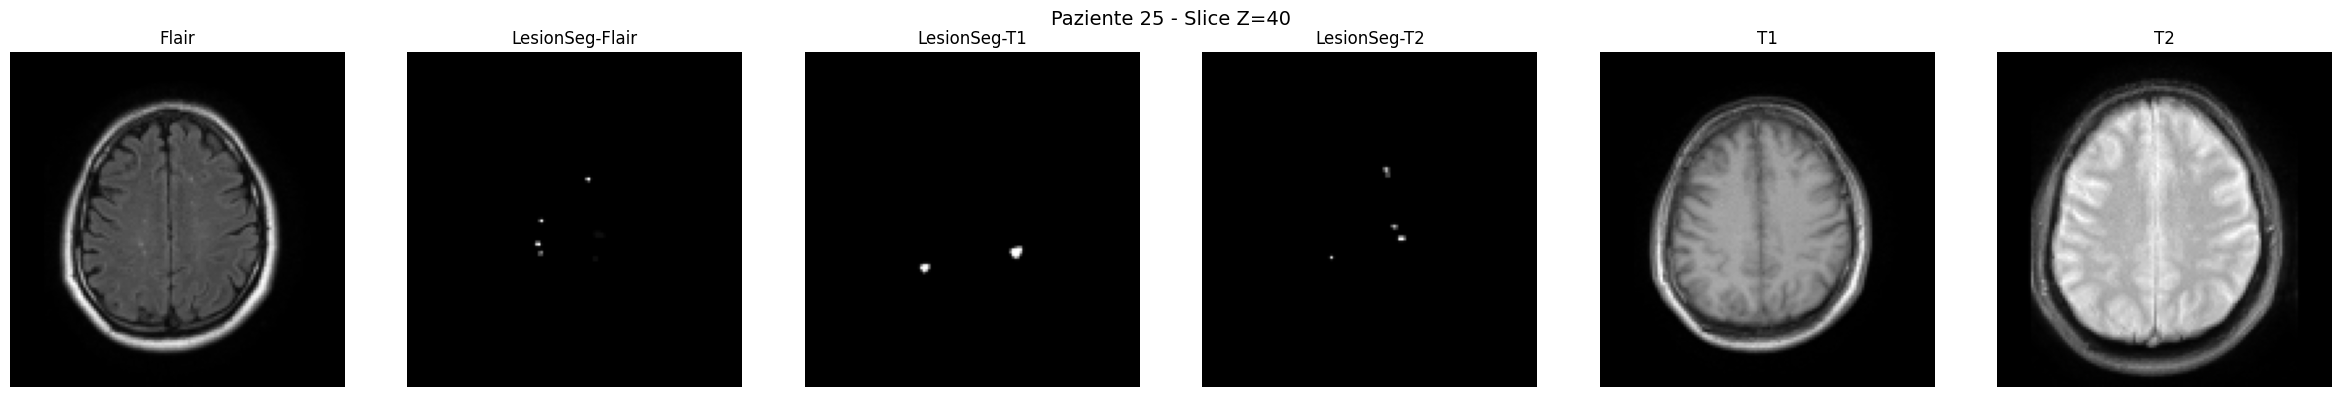

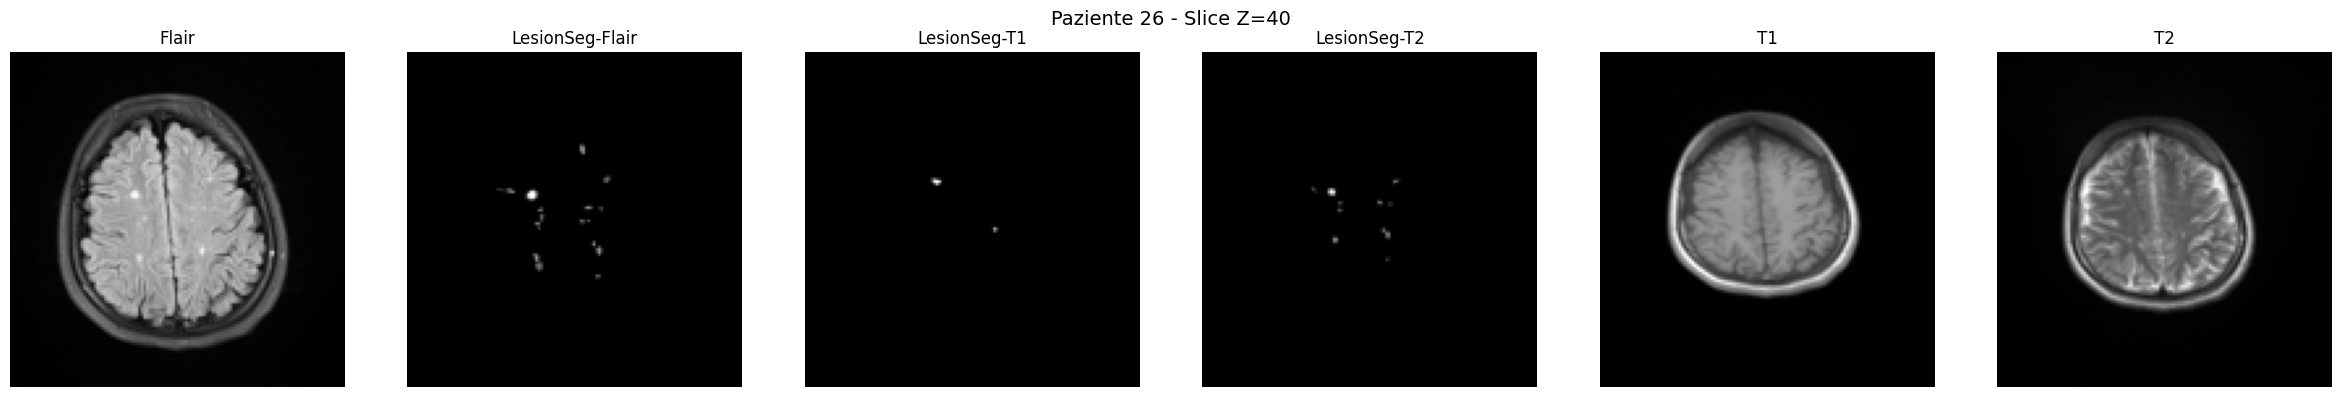

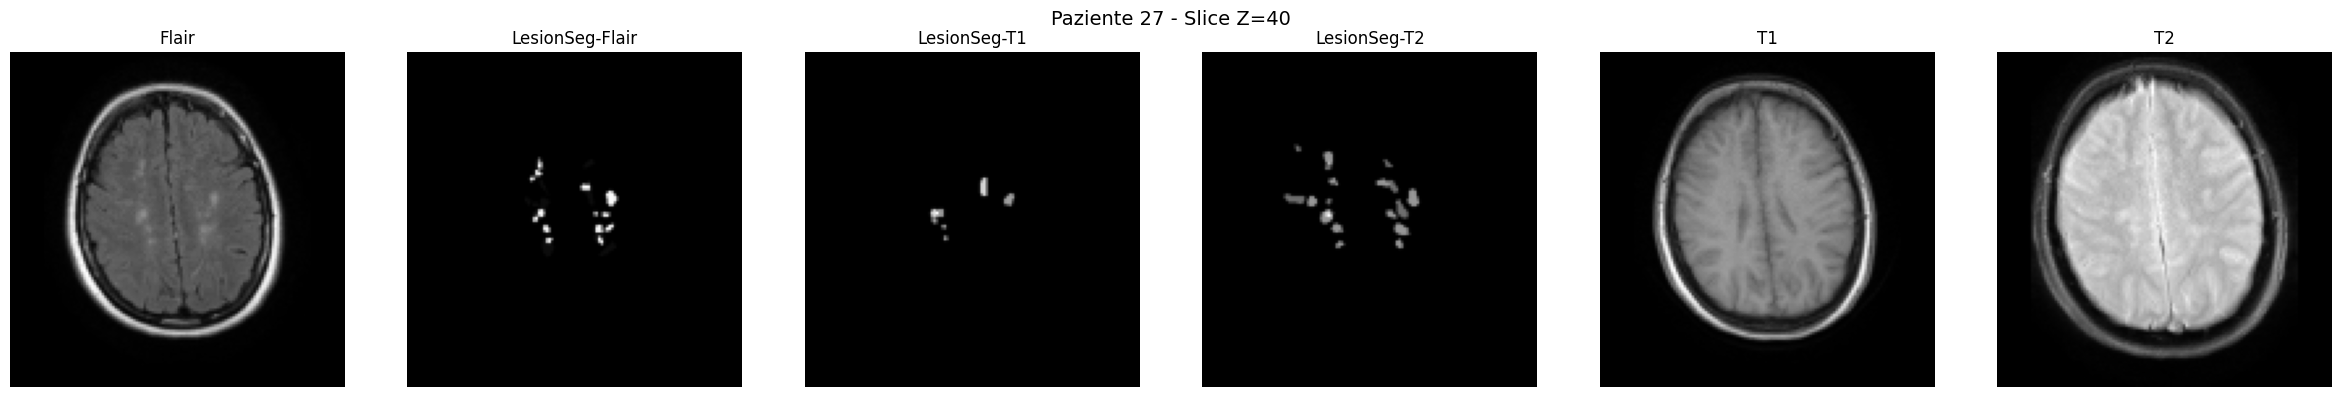

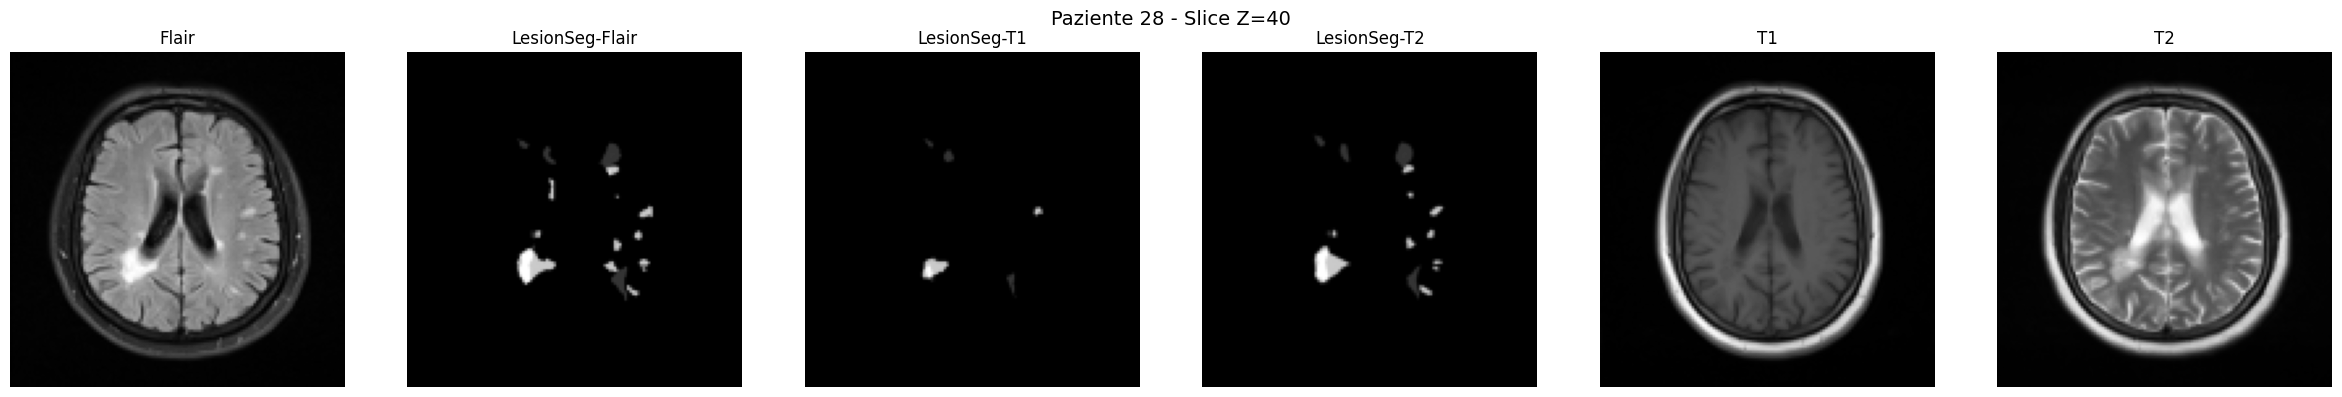

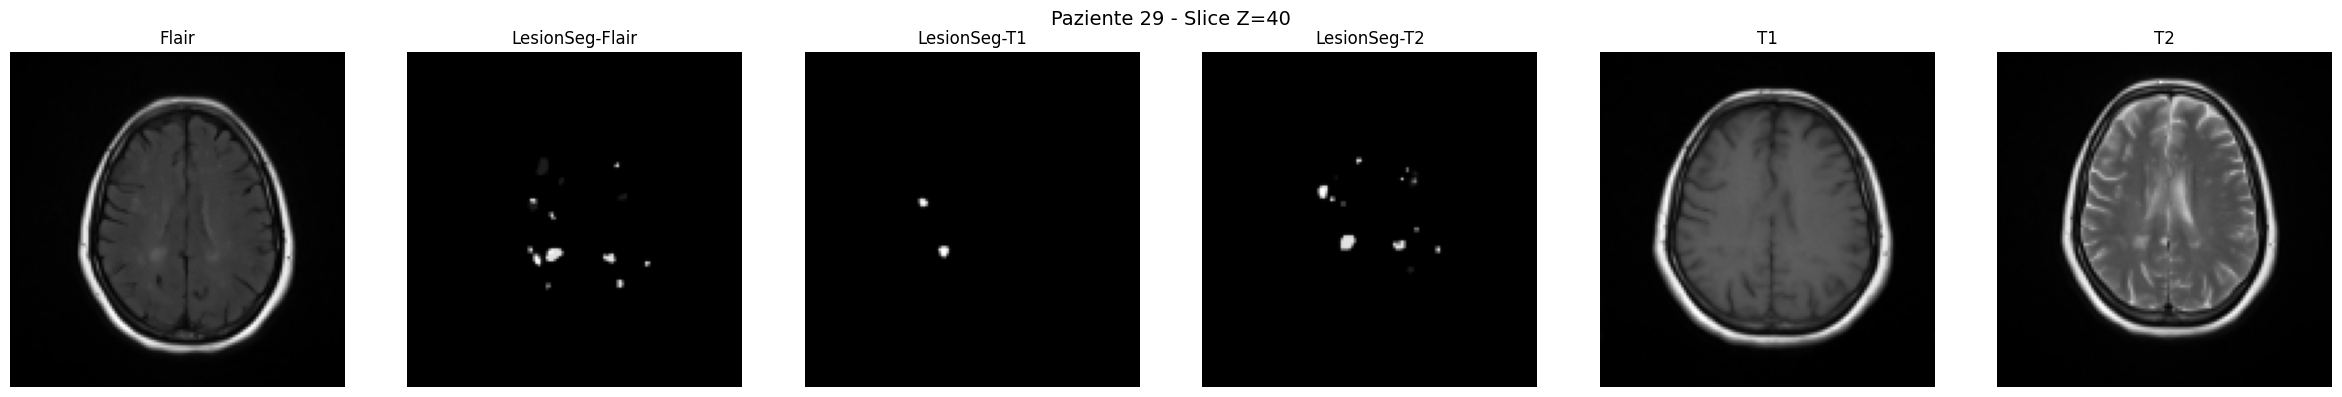

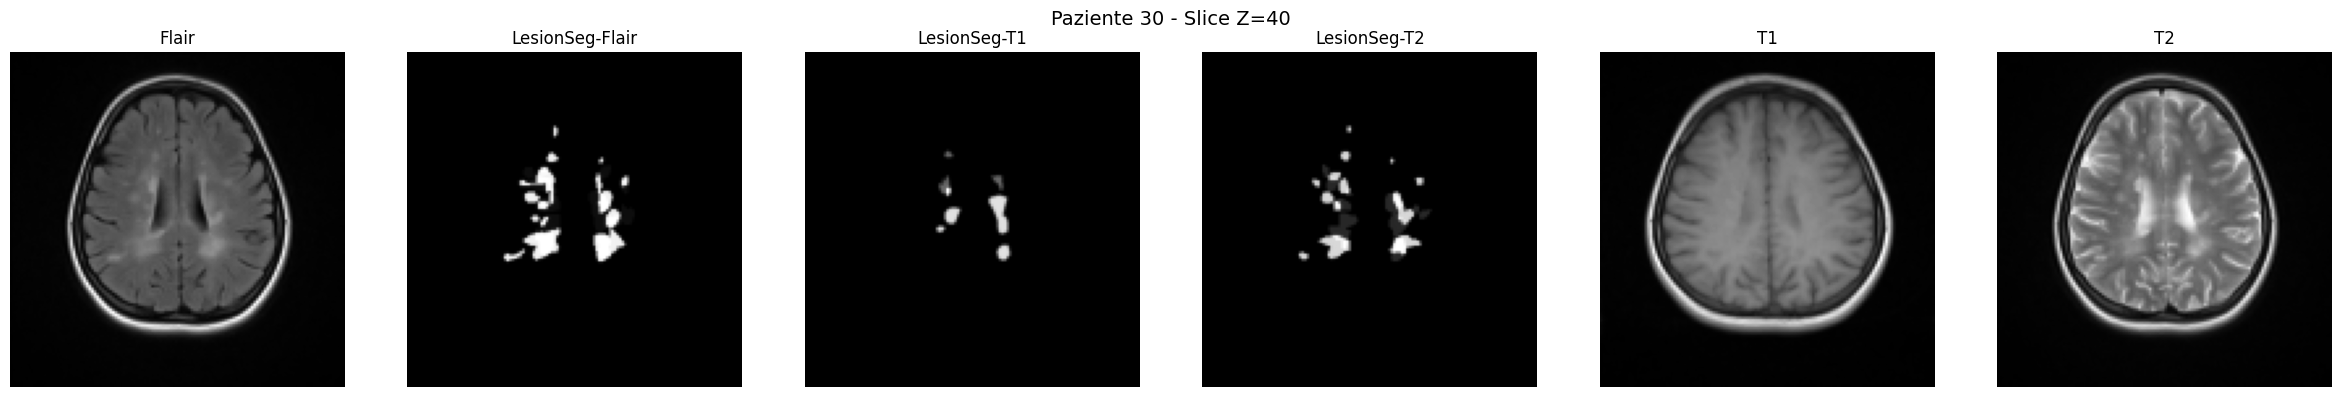

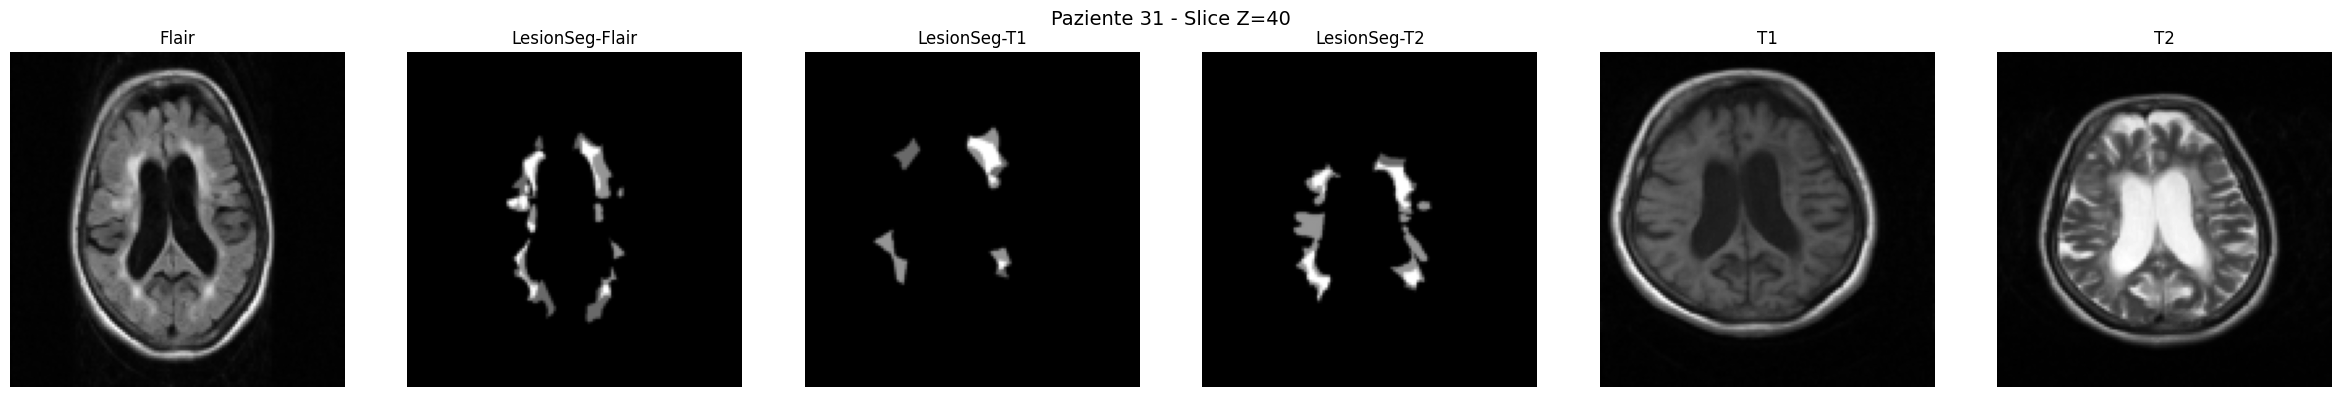

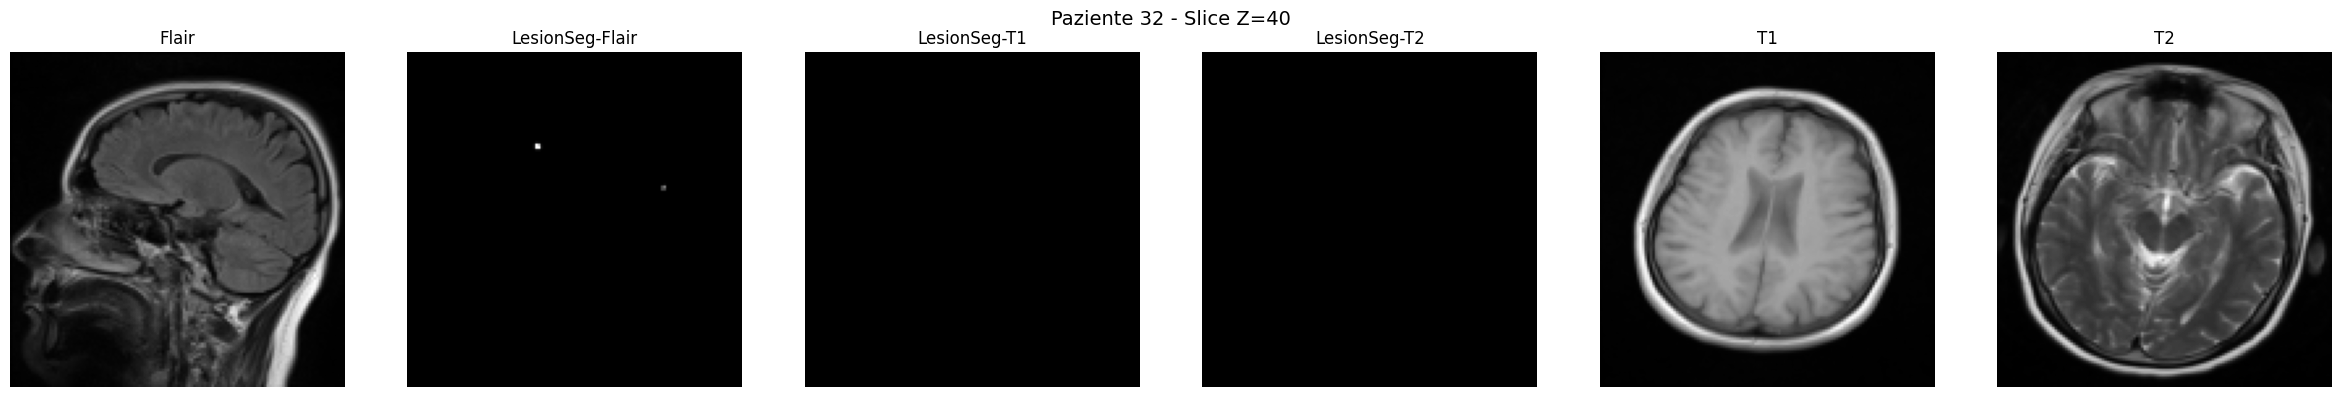

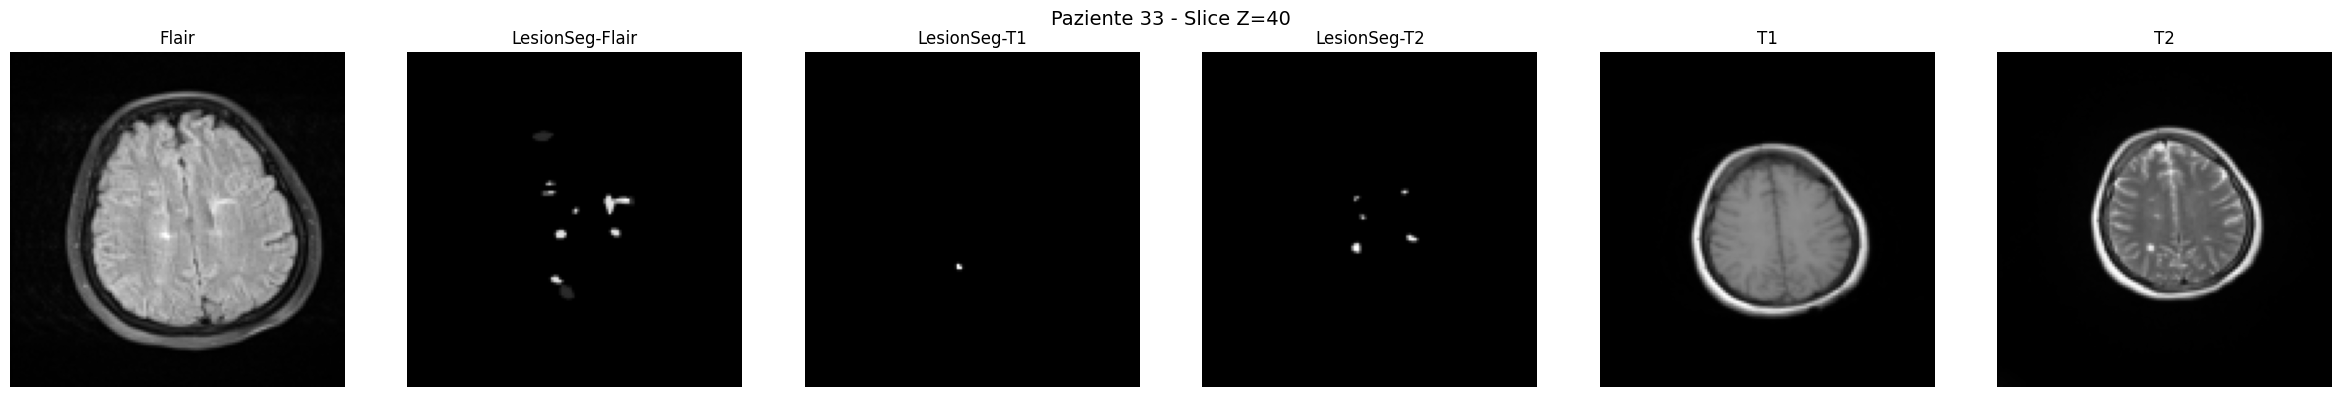

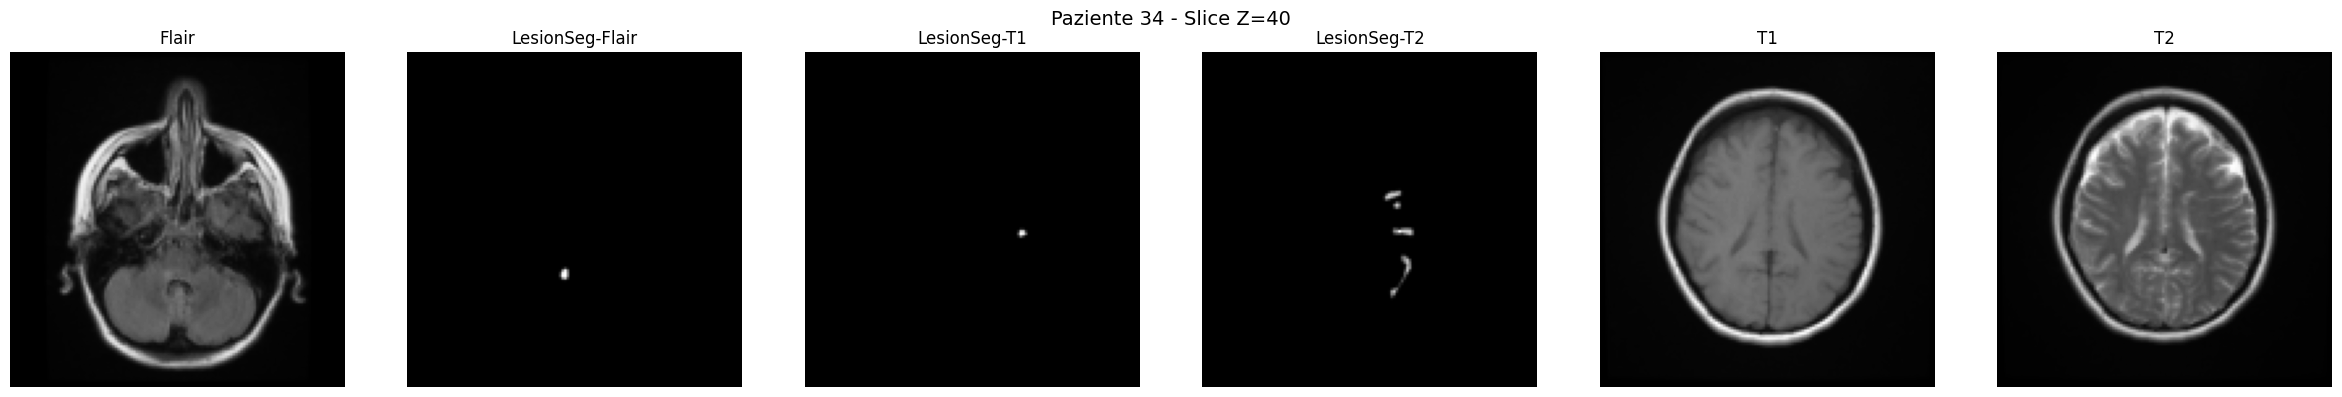

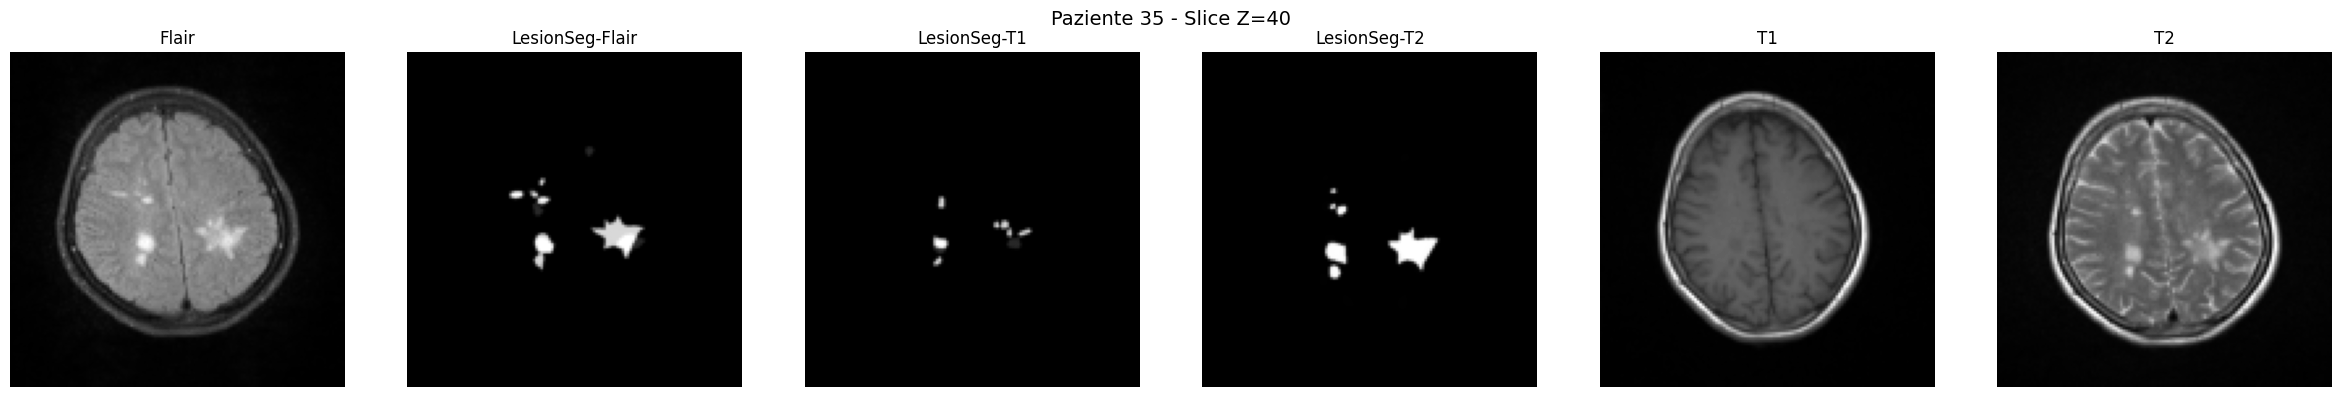

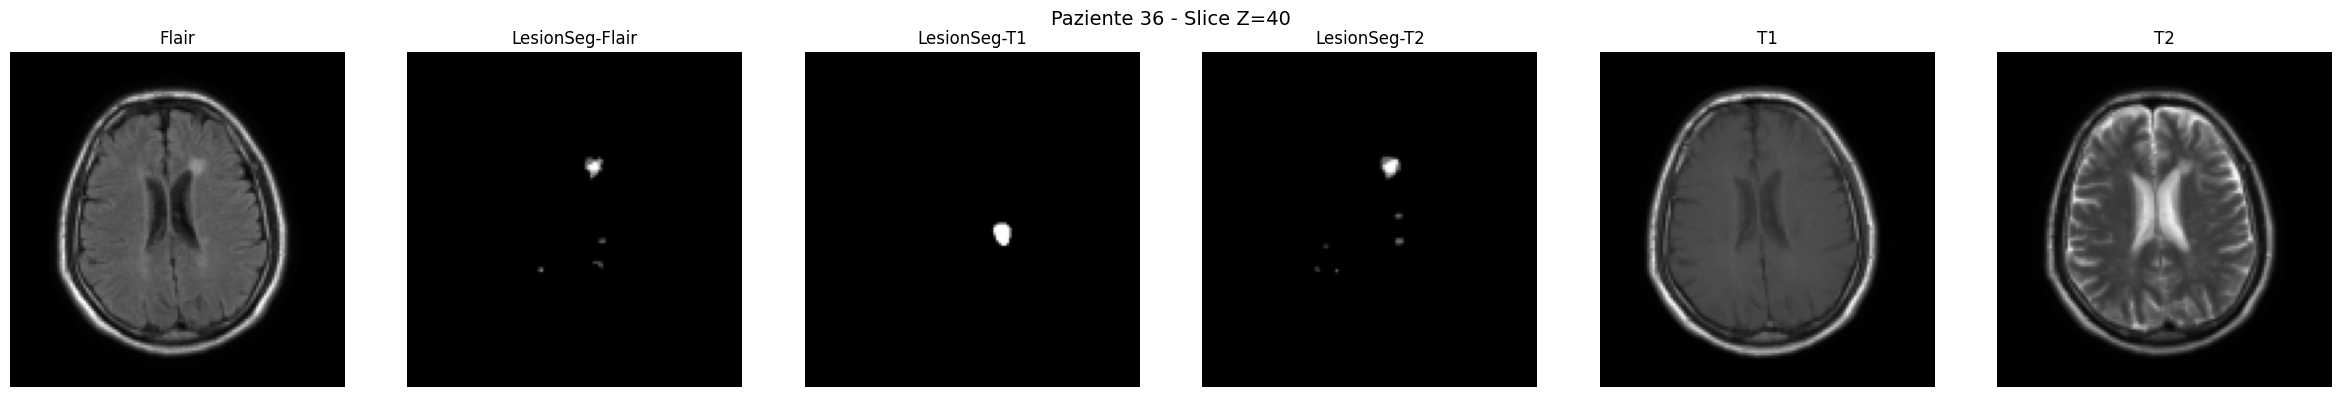

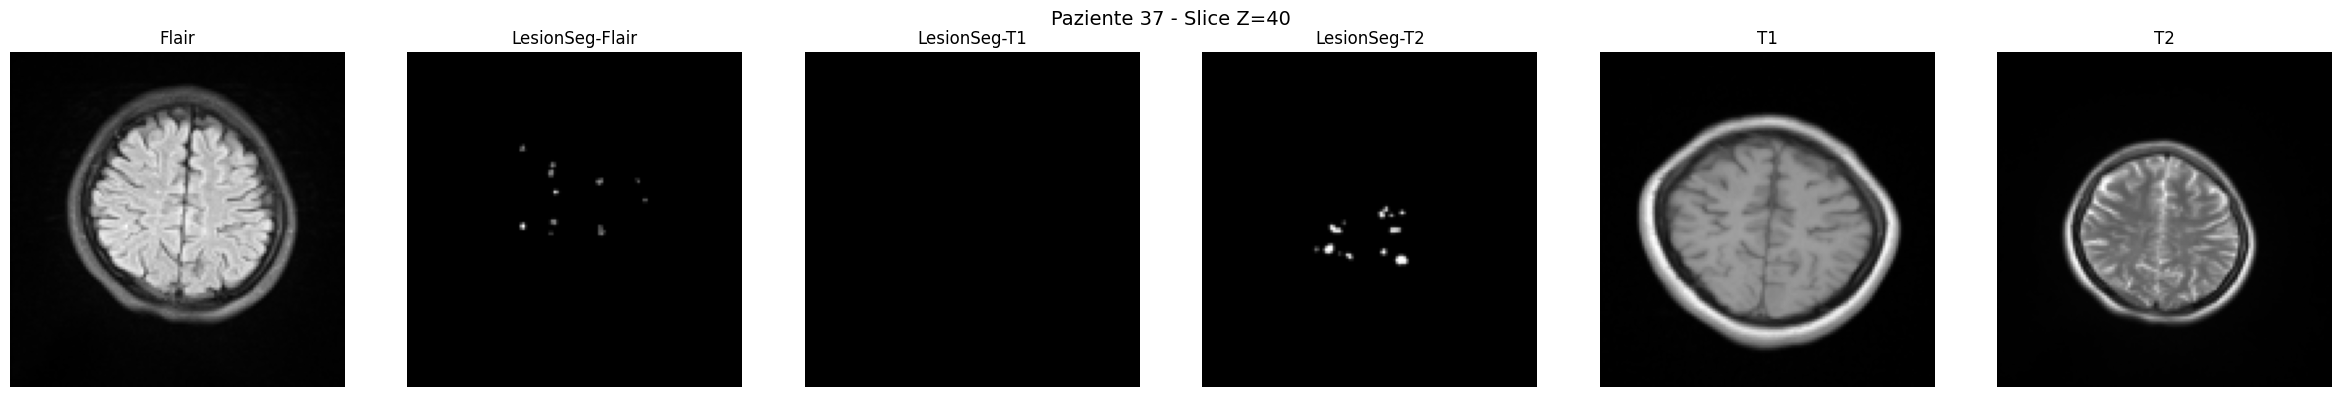

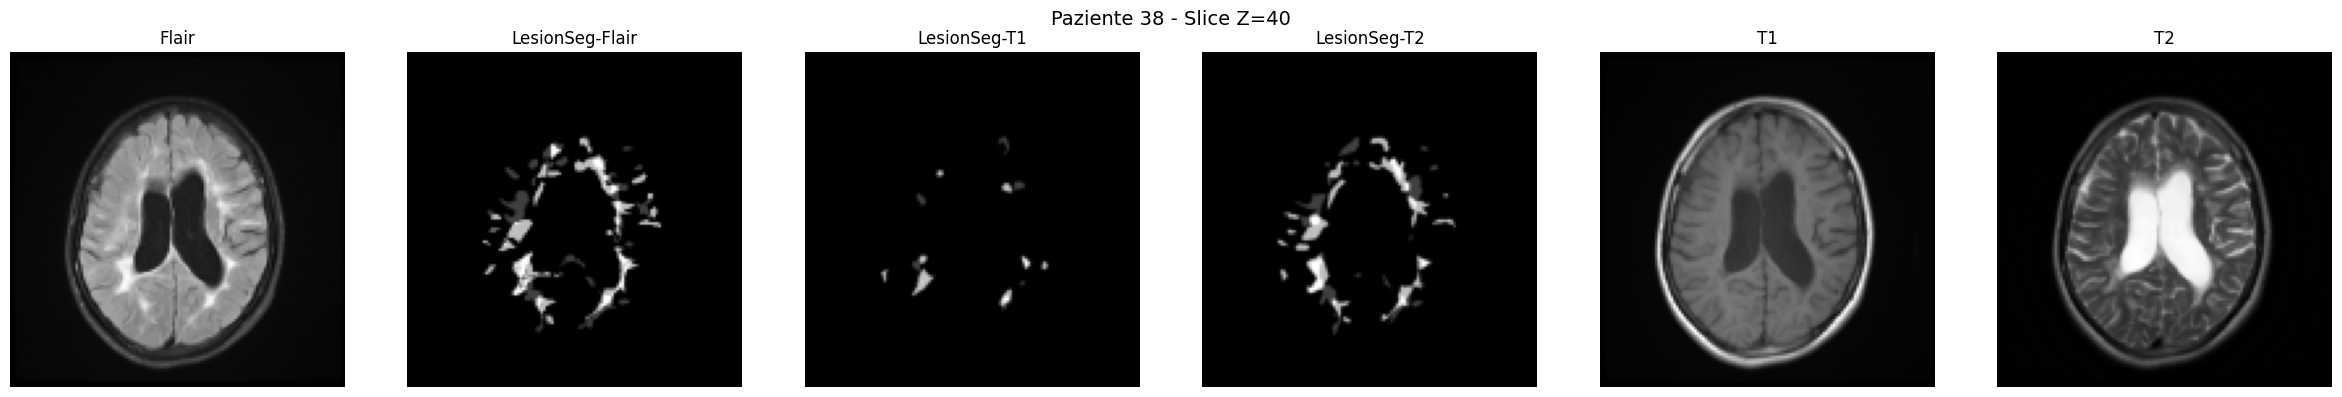

In [ ]:
# Visualizzazione immagini pazienti
def visualizza_pazienti(image_data, num_pazienti=60, slice_idx=40):
    """
    Mostra le immagini di num_pazienti pazienti.
    :param image_data: dizionario con immagini per paziente
    :param num_pazienti: quanti pazienti visualizzare
    :param slice_idx: indice della slice (int o 'center')
    """
    pazienti = sorted(list(image_data.keys()))[:num_pazienti]

    for esempio_id in pazienti:
        images = image_data[esempio_id]
        num_images = len(images)
        fig, axs = plt.subplots(1, num_images, figsize=(4 * num_images, 4))

        if isinstance(axs, plt.Axes):
            axs = [axs]

        for ax, (img_type, img) in zip(axs, images.items()):
            z = img.shape[2] // 2 if slice_idx == 'center' else slice_idx
            ax.imshow(img[:, :, z], cmap="gray")
            ax.set_title(img_type)
            ax.axis("off")

        plt.suptitle(f"Paziente {esempio_id} - Slice Z={z}", fontsize=14)
        plt.tight_layout()
        plt.show()

visualizza_pazienti(image_data, num_pazienti=60)

In [1]:
# Estrazione feature da immagini (statistiche semplici)
def estrai_feature_immagini(image_data):
    """
    Estrae feature statistiche (mean, std, volume) per ogni tipo di immagine.
    """
    feature_list = []
    pazienti = []

    for paziente_id, immagini in tqdm(image_data.items(), desc="Estrazione feature"):
        features = {}

        for tipo, img in immagini.items():
            features[f"{tipo}_mean"] = np.mean(img)
            features[f"{tipo}_std"] = np.std(img)

            # Per segmentazioni, calcola volume (voxel > 0.5)
            if "LesionSeg" in tipo:
                features[f"{tipo}_lesion_volume"] = np.sum(img > 0.5)
                features[f"{tipo}_lesion_ratio"] = np.mean(img > 0.5)

        feature_list.append(features)
        pazienti.append(paziente_id)

    return pd.DataFrame(feature_list, index=pazienti)

# Esegui estrazione
X_image = estrai_feature_immagini(image_data)
print(X_image.shape)
X_image.head(60) #imposto a 60, perché di default mi da soltanto le prime 5 righe


NameError: name 'image_data' is not defined